---


# Kuromi vs Cinnamoroll — Clasificador Binario con Transfer Learning

**Diplomado Superior en Redes Neuronales Artificiales y Deep Learning (UAEM)**  
**Módulo 4: Deep Learning | Proyecto: Kuromi_vs_Cinnamoroll**


## ¿Qué estamos construyendo?

Imagina que tienes un montón de figuras de Sanrio revueltas
y quieres un robot que las clasifique automáticamente.

Eso exactamente es este proyecto:
un **clasificador binario** que mira una foto y dice:

> "Esto es **Kuromi**" (?) o "Esto es **Cinnamoroll**" (?)".

### ¿Para qué sirve en la vida real?

Esto no es solo un juguete. La misma técnica se usa para:

| Aplicación real | Equivalente a |
|----------------|---------------|
| Diagnóstico médico: ¿tumor benigno o maligno? | Kuromi vs Cinnamoroll |
| Control de calidad: ¿pieza buena o defectuosa? | Kuromi vs Cinnamoroll |
| Moderación de contenido: ¿imagen apta o no apta? | Kuromi vs Cinnamoroll |
| Seguridad: ¿rostro autorizado o desconocido? | Kuromi vs Cinnamoroll |

Todos son problemas de **clasificación binaria**. Aprender con Sanrio
es más divertido, pero el conocimiento se transfiere 1:1.

### El plano de la construcción

```
Fotos de figuras  -->  ResNet18 (ya sabe ver)  -->  ¿Kuromi o Cinnamoroll?
                         |
                  Solo le enseñamos
                  a distinguir estas 2
```

### Cómo leer este notebook

Cada sección tiene:
1. **¿Qué vamos a hacer?** (markdown)
2. **¿Por qué?** (markdown - la intuición)
3. **El código** (con comentarios explicativos)
4. **¿Qué observar?** (markdown - reflexión)

> ¿Lista para empezar? Corre cada celda en orden.
> Si algo no se entiende, los comentarios en el código lo explican.


---
## 1. Preparando el terreno

### ¿Qué pasa aquí?

Vamos a importar todas las herramientas que necesitamos:

- **PyTorch**: el martillo y los clavos de la construcción
- **torchvision**: planos de ResNet18 ya prefabricados
- **matplotlib**: para dibujar gráficas
- **sklearn**: metro para medir que tan bueno es el modelo

### ¿Por qué detectar la plataforma?

El notebook funciona en **Google Colab** (nube) y en **tu VSCode** (local).
Las rutas de archivos cambian, así que detectamos donde estamos.

### ¿Qué son los hiperparametros?

Son las perillas que podemos ajustar antes de entrenar:

| Perilla | Valor | Analogia |
|---------|-------|----------|
| **BATCH_SIZE = 16** | ¿Cuántos problemas resuelve antes de revisar respuestas? | Cómo estudiar: si resuelves 1 problema y revisas, es lento. Si resuelves 100 y revisas, te confundes. 16 es un buen balance. |
| **LR (learning rate) = 0.001** | ¿Qué tan rápido aprende? | Cómo caminar: paso muy grande (0.1) te tropiezas (diverges). Paso muy chico (0.00001) nunca llegas. 0.001 es el paso "normal" para Adam. |
| **EPOCHS = 10 + 15** | ¿Cuántas veces ve TODO el dataset? | Cómo repasar un libro: la primera vez captas lo general. La decima vez ya te sabes los detalles. 25 veces es suficiente para ~1000 imágenes. |
| **DROPOUT = 0.3** | ¿Cuántas neuronas "apagamos" al azar? | Cómo estudiar con ruido de fondo: si siempre es silencio absoluto, en el examen con ruido te bloqueas. El dropout fuerza al cerebro a no depender de una sola neurona. |

> **Experimento:** Cambia BATCH_SIZE a 32 o 64.
> ¿El entrenamiento es más rápido? ¿La accuracy cambia?
> (Con 8GB de VRAM, batch_size=32 deberia entrar sin problema).


In [1]:
# ============================================
# BLOQUE 1: Imports, plataforma y CONFIG
#
# ¿Qué hace: Prepara todas las herramientas,
#   detecta si estamos en Colab o local, y
#   define los hiperparametros (las perillas).
#
# ¿Variables clave:
#   - EN_COLAB (bool): True si estamos en Google Colab.
#       'google.colab' in sys.modules es True solo alla.
#   - RUTA_BASE (str): carpeta raiz del proyecto.
#       En Colab: /content/drive/...
#       En local: la carpeta donde esta este notebook.
#   - RUTA_DATASET (str): dataset/train/ y dataset/test/
#   - RUTA_MODELOS (str): donde se guarda el .pth entrenado.
#   - device (torch.device): 'cuda' (GPU) o 'cpu'.
#       Con GPU todo es ~10x más rápido que CPU.
#   - CONFIG (dict): todas las perillas juntas.
#
# ¿Por qué estos valores?
#   - batch_size=16: con 8GB de VRAM, 16 imágenes de 224x224
#     caben comodamente en ResNet18. Mas grande = más rápido
#     pero si excedes VRAM, el kernel muere (OOM).
#   - lr=0.001: valor por defecto de Adam, funciona en ~80%
#     de los casos. Es un buen punto de partida.
#   - dropout=0.3: con 941 imágenes, 30% de dropout evita
#     que el modelo memorice sin perder mucha capacidad.
#
# ¿Para experimentar:
#   - Prueba lr=0.01 y lr=0.0001. ¿Qué notas en la loss?
#   - Cambia dropout a 0.5. ¿El modelo aprende más lento?
# ============================================

import sys, io, warnings, copy, time, json
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc


warnings.filterwarnings('ignore')

# --- Detección de plataforma ---
EN_COLAB = 'google.colab' in sys.modules
# 'google.colab' SOLO existe si estamos en Colab
# En VSCode/Jupyter local, sys.modules no lo tiene

if EN_COLAB:
    print('Plataforma: Google Colab')
    from google.colab import files
    from google.colab import drive
    drive.mount('/content/drive')
    RUTA_BASE = '/content/drive/MyDrive/Diplomado/Modulo4/Proyectos/Kuromi_vs_Cinnamoroll'
    RUTA_DATASET = RUTA_BASE + '/dataset'
    RUTA_MODELOS = RUTA_BASE + '/modelos'
else:
    print('Plataforma: Local (VSCode / Jupyter)')
    # __file__ solo existe en scripts .py, no en notebooks interactivos
    # Por eso preguntamos si existe, y si no, usamos os.getcwd()
    RUTA_BASE = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()
    RUTA_DATASET = os.path.join(RUTA_BASE, 'dataset')
    RUTA_MODELOS = os.path.join(RUTA_BASE, 'modelos')

os.makedirs(RUTA_MODELOS, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo:', str(device))
print('Dataset:', RUTA_DATASET)

# --- Autoria y cronometro ---
AUTORA = "Diana Blanco - MorritaConP1to"
INICIO = time.time()

# --- Hiperparametros (las perillas) ---
CONFIG = {
    'BATCH_SIZE': 16,      # número de imágenes por lote
    'EPOCHS_FASE1': 10,    # epochs solo entrenando cabeza
    'EPOCHS_FASE2': 15,    # epochs fine-tuning
    'LR_FASE1': 0.001,     # learning rate para la cabeza nueva
    'LR_FASE2': 0.0001,    # learning rate 10x menor para fine-tuning
    'IMG_SIZE': 224,       # ResNet18 espera 224x224
    'NUM_CLASES': 2,       # Kuromi y Cinnamoroll
    'PACIENTIA_EARLY': 5,  # epochs sin mejora antes de parar
    'DROPOUT': 0.3,        # apagar 30% de neuronas al azar
    'AUTORA': AUTORA,
}
print('CONFIG:', CONFIG)


Plataforma: Local (VSCode / Jupyter)
Dispositivo: cuda
Dataset: d:\Diplomado-RNA\Modulo-4\Proyectos\Kuromi_vs_Cinnamoroll\dataset
CONFIG: {'BATCH_SIZE': 16, 'EPOCHS_FASE1': 10, 'EPOCHS_FASE2': 15, 'LR_FASE1': 0.001, 'LR_FASE2': 0.0001, 'IMG_SIZE': 224, 'NUM_CLASES': 2, 'PACIENTIA_EARLY': 5, 'DROPOUT': 0.3, 'AUTORA': 'Diana Blanco - MorritaConP1to'}


---
## 1.5 ¿Qué es un hiperparametro (y por qué estos)?

### Definición

Un **hiperparametro** es un valor que **nosotros** elegimos ANTES de entrenar.
El modelo NO los aprende solo; nosotros se los decimos.

Se diferencian de los **parametros** (los pesos de las neuronas)
que el modelo SI aprende durante el entrenamiento.

| Concepto | Quien lo define | Ejemplo |
|----------|----------------|---------|
| **Hiperparametro** | Nosotros | batch_size=16, lr=0.001, dropout=0.3 |
| **Parametro** | El modelo al entrenar | Los 11.7M pesos de ResNet18 |

### Analogia: Cocinar una pizza

| Hiperparametro | En la pizza | En el modelo |
|---------------|-------------|-------------|
| batch_size | ¿Cuántas pizzas metes al horno a la vez? | ¿Cuántas imágenes procesa antes de ajustar pesos? |
| learning_rate | ¿Qué tan alto esta el horno? | ¿Qué tan grande es cada ajuste? |
| epochs | ¿Cuántas veces horneas la misma pizza? | ¿Cuántas veces ve TODO el dataset? |
| dropout | ¿Cuántos ingredientes se caen al piso? (a proposito) | ¿Cuántas neuronas ignoramos para evitar dependencia? |

### ¿Por qué estos valores y no otros?

No son magicos. Son puntos de partida basados en experiencia colectiva:

| Hiperparametro | Valor | ¿Por qué este? | ¿Qué pasa si lo cambio? |
|---------------|-------|---------------|------------------------|
| batch_size=16 | 16 | ResNet18 con 224x224 ocupa ~2.5GB VRAM. 16 batch cabe en 8GB con margen. | 32: más rápido pero puede dar OOM. 8: más lento pero estable. |
| lr=0.001 | 0.001 | Valor default de Adam. Funciona en ~80% de los casos. | 0.01: puede divergir (loss sube). 0.0001: aprende muy lento. |
| dropout=0.3 | 0.3 | Con 941 imágenes, 30% de dropout evita overfitting sin perder mucho. | 0.5: más regularización, pero tarda más. 0: overfitting seguro. |

### ¿Es malo copiar valores de otros proyectos?

**No, es lo normal.** Asi funciona la comunidad de ML:
1. Tomas valores que funcionaron en proyectos similares
2. Pruebas
3. Ajustas

Con el tiempo, desarrollas intuición de que valores probar.
Pero incluso los expertos empiezan con valores "default".

> **Dato curioso:** El learning rate 0.001 para Adam se origino en
> el paper original de Adam (2015). 10 años despues, sigue siendo
> el primer valor que prueba todo el mundo.


---
## 2. Data Augmentation: estirando nuestro dataset

### ¿Por qué necesitamos aumentar los datos?

Tenemos ~941 imágenes de entrenamiento. Una red como ResNet18
tiene **11.7 millones de parametros**. Eso es como tener un
rompecabezas de 11.7M piezas con solo 941 fotos de referencia.

Si entrenaramos así nomas, el modelo se aprenderia las fotos
de memoria (overfitting). En el examen (test) fallaria porque
las fotos nuevas son diferentes.

### La solución: "mentirle" al modelo

A cada imagen le aplicamos transformaciones aleatorias que
NO cambian la identidad de la figura:

```
Original  -->  Volteada  -->  Rotada  -->  Con ruido
  (sigue siendo Kuromi)   (sigue siendo Kuromi)  (sigue siendo Kuromi)
```

Esto equivale a multiplicar nuestro dataset.

### Analogia: Lentes de aumento

Es como si para aprender a reconocer a una amiga:

- Sin augmentation: la ves solo de frente, con buena luz, fondo blanco.
  En el examen, la ves de perfil y no la reconoces.

- Con augmentation: prácticas viendola de todos los angulos,
  con distinta luz, con distintos fondos.
  En el examen, la reconoces en cualquier situación.

### Las transformaciones que usamos

| Transformación | ¿Qué hace? | ¿Por qué? | ¿Qué simula? |
|---------------|-----------|-----------|-------------|
| Resize(256) + RandomCrop(224) | Agranda un poco y recorta aleatorio | La figura no siempre esta centrada | Movimiento de cámara |
| RandomHorizontalFlip | Voltea horizontal | La figura puede mirar a cualquier lado | Figura del otro lado |
| RandomRotation(15deg) | Rota ±15 grados | La cámara puede estar inclinada | Foto ladeada |
| ColorJitter | Cambia brillo, contraste, saturación | Las fotos tienen distinta iluminación | Sol/sombra, flash |

> **Analogia visual:** Si tus fotos son de Kuromi siempre
> en tu escritorio con luz de lampara, el modelo pensara que
> "Kuromi = fondo de escritorio con luz amarilla".
> La aumentación rompe esas falsas correlaciones.


In [2]:
# ============================================
# BLOQUE 2: Data Augmentation y carga del dataset
#
# ¿Qué hace: Crea dos pipelines de transformación:
#   - transform_train: CON aumentación (para entrenar)
#   - transform_test: SIN aumentación (solo resize)
#   Luego carga las imágenes con ImageFolder.
#
# ¿Variables:
#   - transform_train (Compose): cadena de transformaciones que se aplican en orden a cada imagen de train.
#     Cada época ve versiones DISTINTAS de la misma imagen.
#   - transform_test (Compose): SOLO redimensiona y normaliza.
#     En test queremos consistencia, no variedad.
#   - train_dataset (ImageFolder): asocia cada imagen con su clase segun la carpeta donde esta.
#     ImageFolder(root='dataset/train') -> asume que cada subcarpeta es una clase.
#   - clases (list): ['cinnamon', 'kuromi'] (orden alfabetico).
#     cinnamon -> indice 0, kuromi -> indice 1.
#   - train_loader (DataLoader): itera sobre el dataset en lotes (batches). shuffle=True evita que el modelo aprenda el orden de las imágenes.
#
# ¿Por qué 256 -> 224?
#   ResNet18 fue entrenada con imágenes de 224x224.
#   Pero si redimensionamos directo a 224, siempre recortamos el mismo cuadrado. 
#   Al agrandar a 256 y recortar 224, el recorte es aleatorio y la figura "se mueve" en el cuadro.
#   Esto es aumentación gratuita.
#
# ¿Por qué los valores de Normalize?
#   mean=[0.485, 0.456, 0.406] NO son inventados.
#   Son la media de cada canal (R,G,B) de TODAS las imágenes de ImageNet (1.2 millones de fotos).
#   ResNet18 fue entrenada con imágenes normalizadas ASI.
#   Si normalizas con otros valores, las features pre-entrenadas no se activan correctamente.
#
# ¿Por qué la normalización? Analogia:
#   Es como si ResNet18 hablara ingles y tu le hablaras en español.
#   La normalización "traduce" tus pixeles al "idioma" que ResNet18 entiende.
#
# ¿Para experimentar:
#   - Comenta RandomHorizontalFlip(). ¿El accuracy baja? (Con figuras simetricas quizas no tanto)
#   - Cambia RandomCrop(224) por Resize(224).
#     ¿El modelo aprende más lento?
#   - Prueba con scale=(0.5, 1.0) en RandomResizedCrop.
#     ¿Ahora la figura puede estar muy lejos?
# ============================================

# --- Pipeline de ENTRENAMIENTO (con aumentación) ---
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),                    # Agrandamos un poco
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # Recorte aleatorio
    transforms.RandomHorizontalFlip(p=0.5),           # Volteo 50% de las veces
    transforms.RandomRotation(degrees=15),            # Rotación leve
    transforms.ColorJitter(brightness=0.2, contrast=0.2,  # Variación de color
                          saturation=0.2),
    transforms.ToTensor(),                             # Pixel (0-255) -> Tensor (0.0-1.0)
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # Estandarizar a "idioma ImageNet"
                         std=[0.229, 0.224, 0.225])
])

# --- Pipeline de TEST (sin aumentación) ---
# En test solo queremos ver que tan bien clasifica, no queremos que la aleatoriedad afecte la evaluación.

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),   # Directo a 224, sin recorte aleatorio
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --- Cargar datasets ---
# ImageFolder mapea: subcarpeta -> clase
# dataset/train/cinnamon/ -> clase 0
# dataset/train/kuromi/   -> clase 1
train_dataset = ImageFolder(root=os.path.join(RUTA_DATASET, 'train'), transform=transform_train)
test_dataset  = ImageFolder(root=os.path.join(RUTA_DATASET, 'test'), transform=transform_test)

# --- DataLoaders ---
# Un DataLoader es como un "iterator inteligente":
# - Toma el dataset
# - Lo divide en grupos de BATCH_SIZE
# - Los mezcla si shuffle=True
# - Los sirve uno por uno al bucle de entrenamiento
BATCH_SIZE = CONFIG['BATCH_SIZE']
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- Info del dataset ---
clases = train_dataset.classes
print('Clases detectadas:', str(clases))
print('  Mapeo:', str(train_dataset.class_to_idx))
print('  Train:', len(train_dataset), 'imágenes')
print('  Test: ', len(test_dataset), 'imágenes')


Clases detectadas: ['cinnamon', 'kuromi']
  Mapeo: {'cinnamon': 0, 'kuromi': 1}
  Train: 941 imágenes
  Test:  237 imágenes


---
## 2.5 ¿Qué observamos en los datos?

### Pausa para reflexionar

Antes de seguir, respondete mentalmente:

1. **¿Cuántas imágenes tenemos por clase?**
   - Si están desbalanceadas (ej: 800 Kuromi vs 200 Cinnamon),
     el modelo tendra preferencia por la clase mayoritaria.

2. **¿Las imágenes de test representan bien la realidad?**
   - Si las fotos de test son muy parecidas a las de train,
     el accuracy va a ser optimista (no mide generalización).

3. **¿Qué clase es la 0 y cuál la 1?**
   - ImageFolder asigna en ORDEN ALFABETICO de subcarpetas.
   - 'cinnamon' va antes que 'kuromi' (c > k).
   - Entonces: cinnamon = clase 0, kuromi = clase 1.

### ¿Por qué importa que clase es 0 y cuál es 1?

En la **curva ROC** (que veremos despues):
- La "clase positiva" (clase 1) es la que nos interesa detectar
- La "clase negativa" (clase 0) es el fondo

Aqui no hay una clase "más importante", pero en medicina:
> Clase 0 = sano, Clase 1 = enfermedad.
> Queremos maximizar detección de clase 1 aunque tenga falsos positivos.

### ¿Qué podemos hacer si las clases están desbalanceadas?

| Problema | Solución |
|----------|----------|
| Muchas más imágenes de una clase | Hacer que el DataLoader tenga pesos (weighted sampler) |
| Muy pocas imágenes en test (< 30) | Las métricas no son confiables |
| Mucha variación dentro de una clase | Mas aumentación o más datos |

En nuestro caso, las clases están balanceadas (~470 c/u de train,
~118 c/u de test). Podemos seguir tranquila.


---
## 3. Visualizando nuestras figuras

¿Qué mejor que verlas? Vamos a mostrar algunas imágenes
del dataset para confirmar que la carga fue correcta.

Esto también sirve para:
- Detectar errores: ¿hay una imagen de Hello Kitty en kuromi/?
- Ver la aumentación: las imágenes de train se ven "diferentes"
  cada vez que las cargas.


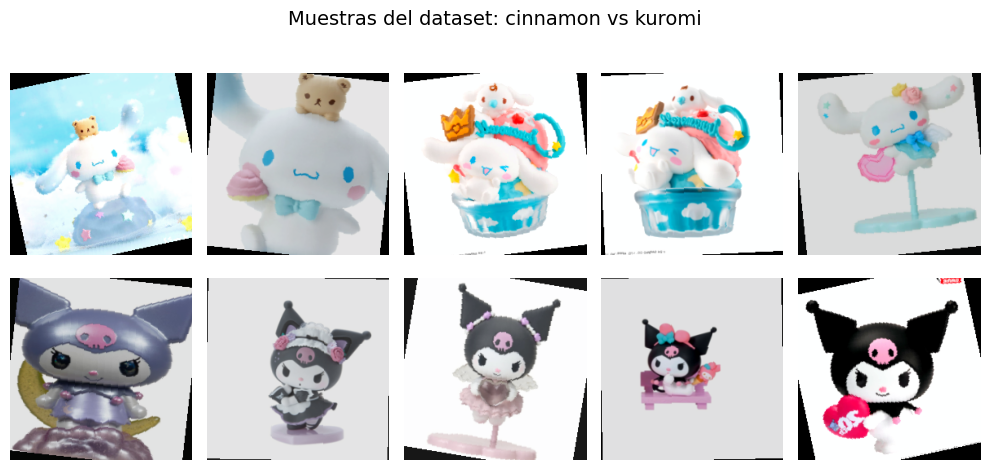

In [3]:
# ============================================
# BLOQUE 3: Visualizar muestras del dataset
#
# ¿Qué hace: Toma algunas imágenes de cada clase y las dibuja en una cuadricula.
#
# ¿Variables:
#   - mostrar_muestras(dataset, clases, num_por_clase):
#     Función que:
#     1. Encuentra los primeros N indices de cada clase
#     2. Carga esas imágenes (aplicando transform)
#     3. Las "desnormaliza" para mostrar colores reales
#     4. Las dibuja en una cuadricula
#
# ¿Por qué desnormalizar?
#   La normalización convierte pixeles a valores que pueden ser negativos o > 1. 
#   Para MOSTRAR la imagen, tenemos que revertir el proceso:
#   img * std + mean.
#   Si no, la imagen se ve verde/azul raro.
#
# ¿Por qué np.clip(img, 0, 1)?
#   Despues de desnormalizar, algunos pixeles pueden quedar fuera del rango [0,1]. clip() los corta ahi.
#   Si no, matplotlib muestra advertencias o colores extraños.
#
# ¿Para experimentar:
#   Cambia num_por_clase a 10 para ver más ejemplos.
#   ¿Hay alguna imagen que no corresponda?
#   ¿Las aumentaciones se notan? (ejecuta esta celda VARIAS veces y mira si las imágenes cambian, porque la aumentación es aleatoria).
# ============================================

def mostrar_muestras(dataset, clases, num_por_clase=5):
    fig, axes = plt.subplots(len(clases), num_por_clase,
                             figsize=(num_por_clase * 2, len(clases) * 2.5))
    if len(clases) == 1:
        axes = axes.reshape(1, -1)

    for idx_clase, clase in enumerate(clases):
        indices = [i for i, (_, label) in enumerate(dataset) if label == idx_clase]
        indices = indices[:num_por_clase]

        for j, idx in enumerate(indices):
            img, _ = dataset[idx]
            # Desnormalizar para visualización
            img = img.numpy().transpose(1, 2, 0)  # de (C,H,W) a (H,W,C)
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img = img * std + mean
            img = np.clip(img, 0, 1)

            axes[idx_clase, j].imshow(img)
            axes[idx_clase, j].axis('off')
            if j == 0:
                axes[idx_clase, j].set_ylabel(clase, fontsize=12, fontweight='bold')

    plt.suptitle('Muestras del dataset: ' + ' vs '.join(clases), fontsize=14)
    plt.tight_layout()
    plt.show()

mostrar_muestras(train_dataset, clases)


---
## 4. Guia para tomar buenas fotos

Si en el futuro quieres agregar más figuras,
esta guia te ayuda a tomar fotos que el modelo aproveche mejor.

### ¿Cuántas fotos por figura?

| Tipo | Fotos sugeridas | ¿Por qué? |
|------|----------------|-----------|
| Figura individual | 8-12 fotos | Variar angulos y fondos |
| Legos / versiones mini | 6-8 fotos | Mas pequeñas, menos detalle |
| Mega figura / peluche | 10-15 fotos | Mas grande, más detalle que capturar |
| Llaveros / accesorios | 4-6 fotos | Pequeños, menos variación posible |

### ¿Cómo deben ser las fotos?

| Hacer | Evitar | ¿Por qué? |
|------|--------|-----------|
| Fondo liso | Fondo saturado de patrones | El modelo podria aprender el fondo en vez de la figura |
| Buena luz | Sombra dura o contraluz | Las sombras fuertes ocultan detalles de la figura |
| Figura centrada (~70% del encuadre) | Figura muy pequeña o recortada | ResNet18 reduce a 224x224. Si la figura es muy chica en la foto, se pierde detalle |
| Variar angulos | Siempre el mismo ángulo | El modelo necesita aprender la figura en 3D, no solo de frente |
| Variar fondos de colores | Siempre el mismo fondo | Evita que el modelo asocie "Kuromi = fondo azul" |
| Incluir acompanantes | Siempre sola y aislada | Ayuda al modelo a no depender de "objetos extra" para clasificar |

### La regla de oro

> **El modelo debe aprender QUE es la figura, no DONDE esta ni COMO la fotografiaron.**

Si todas las fotos de Kuromi tienen fondo blanco y las de Cinnamoroll
tienen fondo rosa, el modelo aprendera "fondo blanco = Kuromi".
En el examen con fondo neutro, fallara.


---
## 5. Buenas prácticas con datasets

### ¿Por qué pre-procesar las imágenes?

Parece trabajo extra, pero prevenir problemas ahora
ahorra horas de debug despues:

| Problema | Cuando aparece | Solución |
|----------|---------------|----------|
| Imagen corrupta | A media época, el DataLoader truena | Validar con PIL antes |
| Formato WebP/GIF animado | PIL no siempre lo abre | Convertir todo a JPEG |
| Archivo < 5 KB | Descarga fallida, thumbnail roto | Eliminar automáticamente |
| Imagen incorrecta (Hello Kitty) | El modelo aprende ruido | Limpieza manual |

### El flujo completo

```
Scraping / Fotos raw
      |
      v
LIMPIEZA MANUAL (borrar lo incorrecto)
      |
      v
preprocesar_dataset.py (valida, JPEG, elimina corruptos)
      |
      v
split_dataset.py (80% train, 20% test, por MODELO no por foto)
      |
      v
DataLoader (dentro del notebook)
      |
      v
Entrenamiento
```

### Nota sobre la separación train/test

Lo hicimos por **modelo fisico** (figura entera), no por foto.
¿Por qué?

Si tienes 12 fotos de la MISMA figura de Kuromi y pones
9 en train y 3 en test, el modelo ya "vio" esa figura exacta
en train. El test no mide generalización, mide memoria.

En cambio, si UNA figura de Kuromi entera va a test,
el modelo JAMAS la vio. El test es honesto.


---
## 5.5 ¿Qué modelo usamos y por qué?

### La familia ResNet

ResNet (Residual Network) fue un invento revolucionario en 2015:
permitio entrenar redes MUY profundas (hasta 152 capas)
sin que el gradiente desaparezca.

Desde entonces, hay varios tamanos:

| Modelo | Capas | Parametros | VRAM (batch=16) | Tiempo estimado | Ideal con... |
|--------|-------|-----------|-----------------|----------------|-------------|
| **ResNet18** | 18 | **11.7M** | ~2.5 GB | **7 min** | **100-2000 imágenes** |
| ResNet34 | 34 | 21.8M | ~3.5 GB | ~12 min | 500-5000 imágenes |
| ResNet50 | 50 | 25.6M | ~4.5 GB | ~15 min | 1000-10000+ imágenes |
| ResNet101 | 101 | 44.5M | ~7 GB | ~25 min | 5000+ imágenes |
| ResNet152 | 152 | 60.2M | ~9 GB (no entra) | ~35 min | 10000+ imágenes |

### ¿Por qué escogimos ResNet18?

**Analogia del estudiante:**

> ResNet18 es como un estudiante de prepa.
> ResNet50 es como un doctorado.
>
> Les das 1000 libros para estudiar:
> - El de prepa los lee, aprende lo esencial, y aprueba el examen.
> - El doctorado los lee, pero tiene capacidad para más.
>   Cómo no hay más libros, empieza a leer cada pagina 5 veces
>   y a memorizar detalles irrelevantes (overfitting).
>
> El doctorado NO rinde mejor porque el problema no es lo
> suficientemente complejo para justificar su capacidad.

### ¿Y si usamos ResNet34?

Con 941 imágenes de train, ResNet34 estaria al limite:
- Tiene casi el doble de parametros
- Pero los mismos datos
- Probablemente de ~99.2% (vs 99.16% con ResNet18)
- Diferencia insignificante, más riesgo de overfitting

**No vale la pena.** ResNet18 ya nos da 99%+.

### ¿Y si NO fuera Transfer Learning?

Si entrenaramos ResNet18 desde cero (pesos aleatorios):
- Necesitariamos ~1 MILLON de imágenes (como ImageNet)
- Con 941 imágenes, el accuracy sería ~60-70%
- El entrenamiento tomaria ~10x más tiempo

**Transfer Learning es el superpoder que hace posible este proyecto.**

### ¿Y otros modelos no-ResNet?

| Modelo | Ventaja | Desventaja | ¿Para qué usarlo? |
|--------|---------|-----------|-------------------|
| **EfficientNet-B0** | Mejor accuracy/parametro | Menos documentado | Proyectos con presupuesto de computo limitado |
| **MobileNetV3** | MUY rápido y liviano | Menos precisión | Apps moviles, embedded |
| **ViT (Visión Transformer)** | Estado del arte | Necesita >100K imágenes | Proyectos con datasets enormes |
| **ConvNeXt** | Moderno, preciso | Pesado, lento | Investigación de punta |

### Arbol de decisión para elegir modelo

```
¿Cuántas imágenes tienes?
        |
    < 1000 -----> ResNet18
        |
    1000-5000 ---> ResNet34 o EfficientNet-B0
        |
    5000-30000 --> ResNet50
        |
    > 30000 -----> ResNet101, ViT


---
## 6. Transfer Learning: la magia de no empezar de cero

### ¿Qué es?

En lugar de entrenar una red desde cero (como un bebe que no sabe nada),
tomamos una red que ya fue entrenada con **1.2 MILLONES de imágenes**
(ImageNet) y la adaptamos a nuestro problema.

### ¿Qué sabe ya ResNet18?

Despues de ver 1.2M de imágenes, ResNet18 ya sabe reconocer:

| Capa | Reconoce... | ¿Para qué sirve? |
|------|------------|-----------------|
| layer1 | Bordes, esquinas, colores | Cómo los trazos basicos de un dibujo |
| layer2 | Texturas, patrones simples | Cómo rayas, puntos, degradados |
| layer3 | Formas: ojos, orejas, ruedas | Cómo partes de objetos |
| layer4 | Objetos completos: caras, autos, perros | Cómo figuras complejas |

Nosotros solo necesitamos que aprenda:
> "Esto es Kuromi, esto es Cinnamoroll"

### Analogia del chef

> Imagina que contratas a un chef que ya sabe cocinar.
> Sabes que hace platos franceses, pero tu quieres que aprenda
> cocina mexicana.
>
> No le ensenas desde "como pelar una papa" (eso ya lo sabe).
> Solo le ensenas las recetas nuevas (tus ingredientes, tus técnicas).
>
**Eso es Transfer Learning:**
- El chef = ResNet18 pre-entrenada en ImageNet
- Las recetas nuevas = nuestras 941 imágenes de Sanrio
- Pelar papas = detectar bordes, colores, texturas (ya lo sabe)

### La estrategia de 2 fases

```
Fase 1: Solo la cabeza nueva        Fase 2: Ajuste fino de layer4
                                      (aprende detalles de Sanrio)
+--------+                           +--------+
| Cabeza | ENTRENA                   | Cabeza | ENTRENA
| nueva  | >>>>>>>>>                  | nueva  | >>>>>>>>
+--------+                           +--------+
| layer4 | CONGELADO                 | layer4 | ENTRENA (lr bajo)
+--------+                           +--------+
| layer3 | CONGELADO                 | layer3 | CONGELADO
+--------+                           +--------+
| layer2 | CONGELADO                 | layer2 | CONGELADO
+--------+                           +--------+
| layer1 | CONGELADO                 | layer1 | CONGELADO
+--------+                           +--------+
| Input  |                           | Input  |
+--------+                           +--------+
```

### ¿Por qué no descongelar todo?

Porque:
- Las capas tempranas (layer1, layer2) aprenden cosas UNIVERSALES
  (bordes, colores). No necesitan cambiar.
- Si descongelas todo, el modelo puede "olvidar" lo que sabe de ImageNet
  y overfittear a nuestras 941 imágenes.
- Descongelar SOLO layer4 permite ajustar los detalles finos
  (¿qué hace que Kuromi sea Kuromi?) sin perder lo general.


In [4]:
# ============================================
# BLOQUE 6: Crear modelo con Transfer Learning
#
# ¿Qué hace: Carga ResNet18 pre-entrenada y reemplaza su cabeza clasificadora (la capa FC final) por una nueva que clasifica 2 clases en vez de 1000.
#
# ¿Variables:
#   - modelo.fc.in_features: cantidad de features que entran a la cabeza, ResNet18 tiene 512.
#     Este valor lo obtenemos del modelo, no lo inventamos.
#   - nn.Sequential(...): cadena de capas que reemplazan a la FC original de ResNet18.
#   - requires_grad = False: "congela" los pesos para que no se actualicen durante el entrenamiento.
#     Solo la cabeza nueva tendra requires_grad=True.
#
# ¿Por qué 512 -> 256 -> 2 en vez de 512 -> 2?
#   - 512 -> 2 directamente funciona, pero agregar una capa intermedia de 256 con ReLU le da más capacidad a la cabeza para aprender la frontera entre las 2 clases.
#   - El dropout entre medio evita overfitting en esa capa intermedia.
#   - Se llama "cabeza más profunda".
#
# ¿Por qué cargar los pesos de ImageNet?
#   weights=ResNet18_Weights.IMAGENET1K_V1 carga los pesos oficiales. 
#   Sin este argumento, los pesos serian aleatorios y no habria Transfer Learning.
#
# ¿Para experimentar:
#   - Cambia a models.resnet34(weights='IMAGENET1K_V1')
#     ¿Cuántos parametros tiene?
#   - Quita el Dropout intermedio. ¿El accuracy en test baja? (indicador de overfitting)
#   - Prueba con 512 -> 128 -> 2 en vez de 256.
#     ¿Aprende igual?
# ============================================

def crear_modelo_transfer_learning(num_clases=2, congelar=True):
    # Cargar ResNet18 con pesos de ImageNet
    # IMAGENET1K_V1 = la versión original del paper
    modelo = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Congelar todas las capas (opcional)
    if congelar:
        for param in modelo.parameters():
            param.requires_grad = False
            # requires_grad = False significa:
            # "no actualices estos pesos durante el entrenamiento"

    # Obtener el número de features de la ultima capa
    num_features = modelo.fc.in_features
    # modelo.fc es la cabeza original (512 -> 1000 clases)
    # in_features = 512 (entrada a la FC)

    # Reemplazar la cabeza por una nueva para 2 clases
    modelo.fc = nn.Sequential(
        nn.Dropout(0.3),             # Apagar 30% de neuronas al azar
        nn.Linear(num_features, 256),# Capa oculta: 512 -> 256
        nn.ReLU(),                   # Activación (solo valores positivos)
        nn.Dropout(0.2),             # Otro dropout, más suave
        nn.Linear(256, num_clases)   # Salida: 256 -> 2 (Kuromi/Cinnamon)
    )

    return modelo

# Crear modelo (fase 1: congelado)
model = crear_modelo_transfer_learning(num_clases=2, congelar=True)
model = model.to(device)

# Contar parametros
total = sum(p.numel() for p in model.parameters())
entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('Modelo ResNet18 creado')
print('  Parametros totales:', f'{total:,}')
print('  Parametros entrenables (cabeza):', f'{entrenables:,}')
print('  Proporción entrenable: {:.2f}%'.format(100 * entrenables / total))


Modelo ResNet18 creado
  Parametros totales: 11,308,354
  Parametros entrenables (cabeza): 131,842
  Proporción entrenable: 1.17%


---
## 7. Configuración del entrenamiento: dos fases

### ¿Por qué dos fases?

**Analogia: Aprender a bailar**

> **Fase 1:** Primero aprendes los pasos basicos por separado
>   (el profesor te guia, tu solo sigues el ritmo).
>   Esto es como entrenar solo la cabeza: el cuerpo (ResNet18)
>   ya sabe bailar, solo necesita aprender tu canción.
>
> **Fase 2:** Ya sabes los pasos, ahora los ejecutas con
>   tu propio estilo (fine-tuning). Pero con cuidado:
>   si cambias mucho tu forma de bailar, puedes olvidar
>   los pasos basicos.
>   Por eso el learning rate es 10x menor en Fase 2.

### Los hiperparametros de cada fase

| Parametro | Fase 1 (Cabeza) | Fase 2 (Fine-tuning) | ¿Por qué la diferencia? |
|-----------|----------------|---------------------|------------------------|
| Capas entrenables | Solo FC (0.1% del modelo) | FC + layer4 (~30% del modelo) | Fase 1: la cabeza nueva no sabe nada, necesita aprender rápido. Fase 2: layer4 ya sabe algo, solo necesita ajustes finos. |
| Learning Rate | 0.001 | 0.0001 (10x menor) | Si usas lr=0.001 en Fase 2, el modelo "olvida" ImageNet y overfitea. |
| Optimizer | Adam (default) | Adam (default) | Adam funciona bien en ambos casos. |
| Epocas | 10 | 15 | La cabeza nueva necesita menos épocas (solo 512->256->2). Layer4 necesita más (tiene muchos pesos que ajustar). |

### Early Stopping: saber cuando parar

Si la loss de test NO mejora en 5 épocas consecutivas,
detenemos el entrenamiento automáticamente.

**Analogia:** Si en un examen de práctica sacas 99, luego 99,
luego 98, luego 99... seguir estudiando no va a mejorar tu nota.
Mejor para ahi y evitas sobre-entrenarte.


In [5]:
# ============================================
# BLOQUE 7: Función de pérdida y optimizadores
#
# ¿Qué hace: Define como se mide el error (criterion) y los optimizadores para cada fase.
#
# ¿Variables:
#   - criterion = CrossEntropyLoss()
#     Mide que tan lejos esta la predicción de la etiqueta real.
#     Valor bajo = bien. Valor alto = mal.
#     CrossEntropy combina:
#       - Softmax: convierte las salidas en probabilidades (sum=1)
#       - Log loss: penaliza más los errores con alta confianza
#   - optimizer_fase1: Solo actualiza los pesos de model.fc
#     filter(lambda p: p.requires_grad, model.parameters()) toma SOLO los parametros que no están congelados.
#   - ReduceLROnPlateau: si la loss de test deja de mejorar divide el learning rate por 2 (factor=0.5).
#     Esto permite "aterrizar" con más precisión cuando el modelo ya esta cerca del óptimo.
#
# ¿Por qué CrossEntropy y no otra loss?
#   Es la función de pérdida ESTANDAR para clasificación.
#   Para 2 clases, es equivalente a Binary Cross Entropy.
#   Si usaras MSE (error cuadratico medio), el modelo tardaria mucho más en converger (las probabilidades son valores entre 0 y 1, MSE no esta disenado para eso).
#
# ¿Por qué Adam?
#   - SGD clásico: learning rate fijo, puede atascarse
#   - Adam: learning rate ADAPTATIVO (cada parametro tiene su propia tasa). Mas rápido y estable.
#   - Es el optimizador más usado en Deep Learning (2026).
#
# ¿Para experimentar:
#   - Cambia optimizer por optim.SGD(...)
#     ¿El entrenamiento es más lento? ¿Mas estable?
#   - Cambia factor=0.5 por factor=0.1 (ReduceLROnPlateau)
#     ¿El learning rate baja muy rápido?
# ============================================

criterion = nn.CrossEntropyLoss()

# Fase 1: Solo entrenar la cabeza clasificadora
optimizer_fase1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG['LR_FASE1']
)

scheduler_fase1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_fase1, mode='min', factor=0.5, patience=3
)

print('Fase 1 lista: solo cabeza clasificadora (lr={})'.format(CONFIG['LR_FASE1']))
print('Fase 2 (despues): fine-tuning capas superiores (lr={})'.format(CONFIG['LR_FASE2']))


Fase 1 lista: solo cabeza clasificadora (lr=0.001)
Fase 2 (despues): fine-tuning capas superiores (lr=0.0001)


---
## 7.5 ¿Por qué dos fases y no una sola?

### ¿Qué pasaria si entrenamos TODO desde el principio?

Si desde la época 1 descongelamos todo y entrenamos con lr=0.001:

| Problema | ¿Por qué pasa? | Consecuencia |
|----------|---------------|-------------|
| La cabeza nueva aprende rápido | Tiene pesos aleatorios, el gradiente es enorme | Cambia demasiado, nunca se estabiliza |
| ResNet18 "olvida" ImageNet | El gradiente de la cabeza nueva "contamina" las capas viejas | Pierde todo lo que sabe de bordes, texturas, formas |
| Overfitting inmediato | 11.7M parametros, 941 imágenes, todo entrenable | Memoriza las fotos de train, falla en test |

**Analogia del chef otra vez:**

> Si al chef nuevo le dices "olvida todo lo que sabes y aprende
> solo mis 10 recetas", va a terminar haciendo 10 platos mediocres.
> En cambio, si le dices "tus técnicas generales están bien,
> solo ajusta los detalles finales" (Fase 1), y luego
> "ahora, con cuidado, ajusta algunos procedimientos"
> (Fase 2), el resultado es mucho mejor.

### La secuencia ideal

```
Epocas 1-10: Fase 1 (cabeza sola)
  - La cabeza aprende a interpretar los features de ImageNet
  - El resto del modelo NO cambia (congelado)
  - La loss baja rápido (la cabeza se adapta)

Epocas 11-25: Fase 2 (fine-tuning)
  - Descongelamos layer4 (las capas de "forma de objeto")
  - learning rate 10x menor (ajustes finos, no cambios bruscos)
  - La loss sigue bajando, pero más lento y estable
  - Si la loss de test deja de mejorar, Early Stopping para
```

### ¿Y si solo hicieramos Fase 1?

El modelo probablemente daria ~95-97% de accuracy.
La Fase 2 es la que permite llegar a 99%+.

### ¿Y si solo hicieramos Fase 2?

La cabeza nueva (con pesos aleatorios) recibiria gradientes
enormes en las primeras épocas, desestabilizando layer4.
La Fase 1 "pre-entrena" la cabeza para que cuando llegue
la Fase 2, los gradientes sean pequeños y estables.


---
## 8. La función de entrenamiento (el corazon del proyecto)

### ¿Qué hace esta función?

Bucle que se repite por cada época:

```
Por cada época:
    1. Modo entrenamiento:
       - Toma un lote de 16 imágenes
       - Las pasa por el modelo
       - Calcula el error (loss)
       - Ajusta los pesos (backpropagation)
       - Repite hasta acabar todas las imágenes

    2. Modo evaluación:
       - Pasa TODAS las imágenes de test por el modelo
       - SIN ajustar pesos (solo calcula accuracy)
       - Guarda la loss de test para el scheduler

    3. Reporta: loss train, loss test, accuracy, learning rate

    4. Si la loss de test no mejora en X épocas:
       - Reduce learning rate a la mitad
       - Si pasaron 5 épocas sin mejora: EARLY STOPPING
```

### ¿Qué es "una época"?

Una época = pasar TODAS las imágenes de entrenamiento una vez.

Si tenemos 941 imágenes y batch_size=16:
- 941 / 16 = 58 lotes por época
- 58 lotes x 25 épocas = 1,450 iteraciones totales
- El modelo ve cada imagen 25 veces (cada vez con distinta aumentación)

### ¿Qué esperar ver?

En Fase 1 (10 épocas):
- La loss de train BAJA rápido (de ~0.6 a ~0.2)
- La loss de test TAMBIEN baja
- Accuracy sube de ~85% a ~95%

En Fase 2 (15 épocas):
- La loss de train sigue bajando (de ~0.2 a ~0.05)
- La loss de test baja un poco más
- Accuracy puede llegar a 99%+
- Si la loss de test deja de bajar, el scheduler reduce LR
- Si pasa mucho sin mejorar, Early Stopping


In [6]:
# ============================================
# BLOQUE 8: Función de entrenamiento (reutilizable)
#
# ¿Qué hace: Implementa el bucle completo de entrenamiento + evaluación para una fase.
#   Recibe el optimizador como parametro para poder reutilizarla en Fase 1 y Fase 2.
#
# ¿Parametros:
#   - modelo: el ResNet18 adaptado
#   - train_loader: DataLoader de entrenamiento
#   - test_loader: DataLoader de prueba
#   - criterion: CrossEntropyLoss (función de error)
#   - optimizer: Adam con los params a entrenar
#   - scheduler: ReduceLROnPlateau
#   - num_epochs: cuántas épocas entrenar
#   - device: 'cuda' o 'cpu'
#   - nombre_fase: texto para los logs
#
# ¿Qué retorna:
#   - historial (dict): con listas de train_loss,
#     test_loss, test_acc por cada época.
#     Luego sirve para graficar.
#
# ¿Variables internas importantes:
#   - modelo.train(): activa modo entrenamiento (activa dropout, batch norm se actualiza)
#   - modelo.eval(): activa modo evaluación (desactiva dropout, batch norm fija)
#   - optimizer.zero_grad(): limpia gradientes de la iteración anterior
#   - loss.backward(): calcula gradientes (derivadas de la loss respecto a cada peso)
#   - optimizer.step(): actualiza pesos usando los gradientes
#   - torch.no_grad(): desactiva calculo de gradientes (ahorra memoria, más rápido) Solo para evaluación.
#   - mejor_loss: guarda la mejor loss de test para detectar si estamos mejorando
#   - patience: contador de épocas sin mejora
#
# ¿Por qué torch.no_grad() en test?
#   Cuando evaluamos, NO necesitamos gradientes (no vamos a ajustar pesos). 
#   Desactivarlos ahorra ~40% de memoria y acelera.
#
# ¿Por qué .item() en las losses?
#   loss es un tensor de 1 elemento.
#   .item() lo convierte a número Python.
#   Si no, acumularias tensores y la memoria creceria.
#
# ¿Para experimentar:
#   - Cambia patience a 10 (más épocas antes de early stop).
#     ¿Mejora el accuracy final?
#   - Comenta scheduler.step(test_loss).
#     ¿El learning rate se queda igual siempre?
#     ¿Qué pasa con la convergencia?
# ============================================

def entrenar_biclase(modelo, train_loader, test_loader, criterion,
                     optimizer, scheduler, num_epochs, device,
                     nombre_fase='Fase'):
    historial = {'train_loss': [], 'test_loss': [], 'test_acc': []}
    mejor_loss = float('inf')  # Inicializar con infinito (así cualquiera es mejor)
    patience = 0

    for epoch in range(num_epochs):
        # ---- FASE DE ENTRENAMIENTO ----
        modelo.train()
        train_loss = 0.0

        for imágenes, etiquetas in train_loader:
            imágenes, etiquetas = imágenes.to(device), etiquetas.to(device)

            optimizer.zero_grad()         # Limpiar gradientes previos
            predicciones = modelo(imágenes)  # Forward: calcular salidas
            loss = criterion(predicciones, etiquetas)  # Calcular error
            loss.backward()               # Backward: calcular gradientes
            optimizer.step()              # Actualizar pesos

            train_loss += loss.item()     # Acumular loss de este lote

        train_loss /= len(train_loader)   # Promediar loss de la época
        historial['train_loss'].append(train_loss)

        # ---- FASE DE EVALUACION ----
        modelo.eval()
        test_loss = 0.0
        correctos = 0
        total = 0

        with torch.no_grad():             # Sin gradientes (solo evaluación)
            for imágenes, etiquetas in test_loader:
                imágenes, etiquetas = imágenes.to(device), etiquetas.to(device)
                outputs = modelo(imágenes)
                loss = criterion(outputs, etiquetas)
                test_loss += loss.item()

                _, predichos = torch.max(outputs, 1)  # Clase con mayor probabilidad
                total += etiquetas.size(0)
                correctos += (predichos == etiquetas).sum().item()

        test_loss /= len(test_loader)
        accuracy = 100.0 * correctos / total

        historial['test_loss'].append(test_loss)
        historial['test_acc'].append(accuracy)

        # ---- Reporte ----
        lr_actual = optimizer.param_groups[0]['lr']
        print('{} [{:2d}/{}]  Train Loss: {:.4f}  Test Loss: {:.4f}  Acc: {:.2f}%  LR: {:.6f}'.format(
              nombre_fase, epoch+1, num_epochs, train_loss, test_loss, accuracy, lr_actual))

        # ---- Scheduler y Early Stopping ----
        scheduler.step(test_loss)

        if test_loss < mejor_loss:
            mejor_loss = test_loss
            torch.save(modelo.state_dict(), os.path.join(RUTA_MODELOS, 'mejor_modelo.pth'))
            patience = 0
        else:
            patience += 1
            if patience >= CONFIG['PACIENTIA_EARLY']:
                print('Early stopping en época {} (no mejoro en {} épocas)'.format(
                    epoch+1, CONFIG['PACIENTIA_EARLY']))
                break

    print('{} completada. Mejor accuracy: {:.2f}%'.format(nombre_fase, max(historial['test_acc'])))
    return historial


---
## 9. A entrenar! (Fase 1 + Fase 2)

### ¿Qué va a pasar?

Esto es lo que veras en pantalla:

```
FASE 1 | Epoch 1/10 | Train Loss: 0.4656 | Test Loss: 0.2589 | Acc: 91.56% | LR: 0.001
FASE 1 | Epoch 2/10 | Train Loss: 0.2705 | Test Loss: 0.1935 | Acc: 95.36% | LR: 0.001
...
FASE 2 | Epoch 1/15 | Train Loss: 0.1575 | Test Loss: 0.0587 | Acc: 97.89% | LR: 0.0001
```

**¿Qué mirar?**

| Columna | Valor esperado | ¿Qué significa si es extraño? |
|---------|---------------|------------------------------|
| Train Loss | Baja constantemente | Si sube: learning rate muy alto o bug |
| Test Loss | Baja (debe seguir a Train Loss) | Si sube mientras Train Loss baja: OVERFITTING |
| Acc | Sube y se estabiliza >95% | Si no sube de 70%: hay un problema grave |
| LR | 0.001, baja a 0.0005, etc. | Si nunca baja: el scheduler no se activa |

### ¿Cuánto tarda?

En una RTX 4060 con ~950 imágenes:
- ~32 segundos por época
- Fase 1 (10 épocas): ~5 minutos
- Fase 2 (~9-15 épocas): ~5-8 minutos
- Total: **~10-15 minutos**

En CPU sería ~10x más lento (> 2 horas). La GPU es clave.

### ¿Qué hacer mientras esperas?

Observa las primeras 3 épocas:
- Si el accuracy NO sube de 50% (aleatorio), algo esta mal
- Si la test loss sube desde la época 1, hay un bug
- Si todo va bien, Train Loss baja, Test Loss baja, Acc sube

> **Tip:** Si ves que Test Loss sube pero Train Loss baja,
> el modelo esta overfitteando. Podrias detener y aumentar
> dropout o disminuir épocas.


In [7]:
# ============================================
# BLOQUE 9: Ejecutar Fase 1 y Fase 2
#
# ¿Qué hace: Corre el entrenamiento en 2 fases.
#   Fase 1: solo la cabeza (10 épocas)
#   Fase 2: fine-tuning layer4 + cabeza (~15 épocas)
#
# ¿Variables:
#   - historial1: resultado de Fase 1 (diccionario con train_loss, test_loss, test_acc)
#   - historial2: resultado de Fase 2
#   - historial: combinación de ambos (para graficar)
#
# ¿Por qué descongelar layer4 y no capas anteriores?
#   layer4 es la capa más alta de ResNet18, la que reconoce "formas de objetos". 
#   Justo lo que necesitamos ajustar para distinguir personajes.
#   layer1-3 reconocen bordes y texturas (universales).
#
# ¿Por qué dos optimizadores?
#   optimizer_fase1: solo entrena model.fc (cabeza)
#   optimizer_fase2: entrena model.layer4 + model.fc
#   Podriamos reusar el mismo optimizer, pero es más claro crear uno nuevo para Fase 2.
#
# ¿Por qué lr separado por grupo?
#   optimizer_fase2 tiene 2 grupos de parametros:
#   - layer4 con lr=0.0001
#   - fc con lr=0.0001
#   Ambos tienen el mismo LR, pero podrian ser diferentes
#   (ej: fc con lr=0.001, layer4 con lr=0.0001) si queremos que la cabeza aprenda más rápido.
#
# ¿Para experimentar:
#   - Intercambia el orden: Fase 2 primero, luego Fase 1.
#     ¿Funciona igual? (Spoiler: no, la cabeza nueva desestabiliza layer4 si se entrenan juntos)
#   - Descongela layer3 también. ¿Mejora el accuracy?
#     ¿O overfitea?
# ============================================

# ========== FASE 1: Entrenar solo la cabeza ==========
print('=' * 60)
print('FASE 1: ENTRENANDO CABEZA CLASIFICADORA')
print('=' * 60)

historial1 = entrenar_biclase(
    model, train_loader, test_loader, criterion,
    optimizer_fase1, scheduler_fase1, num_epochs=CONFIG['EPOCHS_FASE1'],
    device=device, nombre_fase='Fase 1'
)

# ========== FASE 2: Fine-tuning ==========
print('\n' + '=' * 60)
print('FASE 2: FINE-TUNING (descongelando layer4)')
print('=' * 60)

# Descongelar layer4 (ultimas capas convolucionales)
for param in model.layer4.parameters():
    param.requires_grad = True

# Optimizador con learning rate 10x menor para fine-tuning
optimizer_fase2 = optim.Adam([
    {'params': model.layer4.parameters(), 'lr': CONFIG['LR_FASE2']},
    {'params': model.fc.parameters(), 'lr': CONFIG['LR_FASE2']}
])

scheduler_fase2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_fase2, mode='min', factor=0.5, patience=3
)

historial2 = entrenar_biclase(
    model, train_loader, test_loader, criterion,
    optimizer_fase2, scheduler_fase2, num_epochs=CONFIG['EPOCHS_FASE2'],
    device=device, nombre_fase='Fase 2'
)

# Combinar historiales para graficar
historial = {
    'train_loss': historial1['train_loss'] + historial2['train_loss'],
    'test_loss': historial1['test_loss'] + historial2['test_loss'],
    'test_acc': historial1['test_acc'] + historial2['test_acc']
}

print('\nEntrenamiento completado.')
print('Mejor accuracy en test: {:.2f}%'.format(max(historial['test_acc'])))


FASE 1: ENTRENANDO CABEZA CLASIFICADORA
Fase 1 [ 1/10]  Train Loss: 0.3723  Test Loss: 0.1635  Acc: 94.51%  LR: 0.001000
Fase 1 [ 2/10]  Train Loss: 0.2495  Test Loss: 0.3126  Acc: 86.08%  LR: 0.001000
Fase 1 [ 3/10]  Train Loss: 0.2642  Test Loss: 0.1385  Acc: 94.94%  LR: 0.001000
Fase 1 [ 4/10]  Train Loss: 0.2392  Test Loss: 0.4588  Acc: 78.48%  LR: 0.001000
Fase 1 [ 5/10]  Train Loss: 0.2725  Test Loss: 0.1438  Acc: 94.94%  LR: 0.001000
Fase 1 [ 6/10]  Train Loss: 0.2304  Test Loss: 0.1257  Acc: 94.94%  LR: 0.001000
Fase 1 [ 7/10]  Train Loss: 0.2119  Test Loss: 0.1493  Acc: 93.25%  LR: 0.001000
Fase 1 [ 8/10]  Train Loss: 0.2705  Test Loss: 0.1338  Acc: 95.36%  LR: 0.001000
Fase 1 [ 9/10]  Train Loss: 0.2518  Test Loss: 0.1298  Acc: 96.20%  LR: 0.001000
Fase 1 [10/10]  Train Loss: 0.1997  Test Loss: 0.1124  Acc: 95.78%  LR: 0.001000
Fase 1 completada. Mejor accuracy: 96.20%

FASE 2: FINE-TUNING (descongelando layer4)
Fase 2 [ 1/15]  Train Loss: 0.1951  Test Loss: 0.1783  Acc: 94.0

---
## 10. Visualizando el progreso

### ¿Qué muestra cada gráfica?

| Gráfica | Eje X | Eje Y | ¿Qué esperar? |
|---------|-------|-------|--------------|
| **Loss** | Epoca | Error (loss) | Dos líneas: azul (train) y roja (test). Deben bajar juntas. Si se separan, overfitting. |
| **Accuracy** | Epoca | % aciertos | Linea verde subiendo hasta estabilizarse. |
| **Comparación** | Fase 1 vs Fase 2 | Mejor accuracy | La Fase 2 debe ser más alta. |
| **Accuracy final** | - | Valor numerico | El número grande. |

La línea punteada vertical separa Fase 1 (izquierda) de Fase 2 (derecha).
Nota como el accuracy suele dar un "salto" al empezar Fase 2.


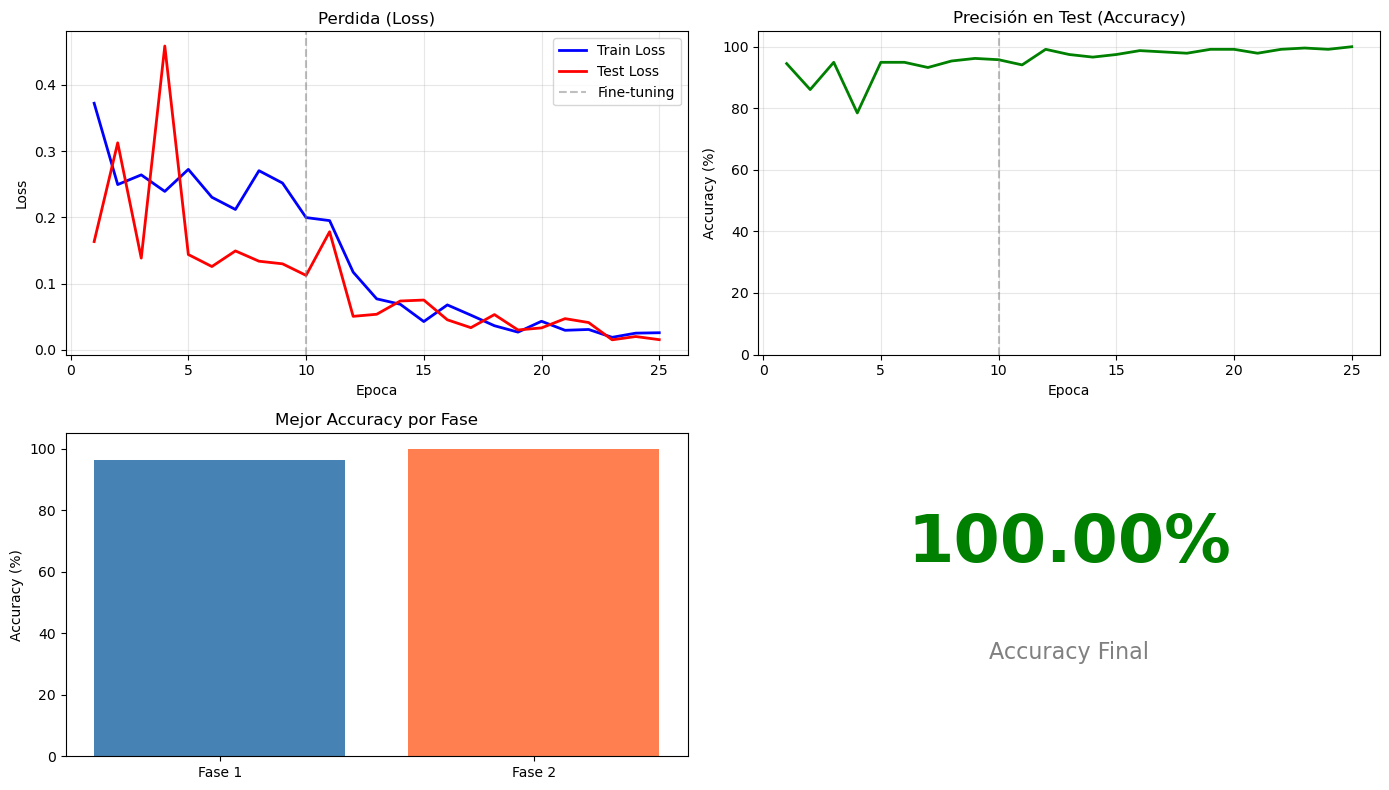

In [8]:
# ============================================
# BLOQUE 10: Gráficas de evolución
#
# ¿Qué hace: Dibuja 4 gráficas en una figura 2x2
#   para visualizar el entrenamiento.
#
# ¿Variables:
#   - sep: punto donde termina Fase 1 y empieza Fase 2
#     len(historial1['train_loss']) = 10 (o menos si early stop)
#   - axvline(x=sep): línea vertical punteada en la separación
#   - historial['train_loss']: lista de losses de train
#   - historial['test_loss']: lista de losses de test
#   - historial['test_acc']: lista de accuracies de test
#
# ¿Por qué 4 gráficas?
#   - Loss: muestra si hay overfitting (train baja, test sube)
#   - Accuracy: muestra la evolución de la métrica principal
#   - Comparación: de un vistazo, ¿mejoro con Fase 2?
#   - Accuracy final: el número grande para presentar
#
# ¿Para experimentar:
#   - Si el accuracy final es > 99%, ¿qué más podemos pedir?
#   - Si la curva de test loss sube al final, es overfitting
#     (necesitamos más dropout o menos épocas)
# ============================================

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 8))

sep = len(historial1['train_loss'])

# Gráfica 1: Loss
ax1.plot(range(1, len(historial['train_loss'])+1), historial['train_loss'],
         'b-', label='Train Loss', linewidth=2)
ax1.plot(range(1, len(historial['test_loss'])+1), historial['test_loss'],
         'r-', label='Test Loss', linewidth=2)
ax1.axvline(x=sep, color='gray', linestyle='--', alpha=0.5, label='Fine-tuning')
ax1.set_title('Perdida (Loss)')
ax1.set_xlabel('Epoca')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfica 2: Accuracy
ax2.plot(range(1, len(historial['test_acc'])+1), historial['test_acc'],
         'g-', linewidth=2)
ax2.axvline(x=sep, color='gray', linestyle='--', alpha=0.5)
ax2.set_title('Precisión en Test (Accuracy)')
ax2.set_xlabel('Epoca')
ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim(0, 105)
ax2.grid(True, alpha=0.3)

# Gráfica 3: Comparación Fase 1 vs Fase 2
ax3.bar(['Fase 1', 'Fase 2'],
        [max(historial1['test_acc']), max(historial2['test_acc'])],
        color=['steelblue', 'coral'])
ax3.set_title('Mejor Accuracy por Fase')
ax3.set_ylabel('Accuracy (%)')
ax3.set_ylim(0, 105)

# Gráfica 4: Accuracy final en grande
ultimo_acc = historial['test_acc'][-1]
ax4.text(0.5, 0.6, '{:.2f}%'.format(ultimo_acc),
         fontsize=48, ha='center', fontweight='bold', color='green')
ax4.text(0.5, 0.3, 'Accuracy Final',
         fontsize=16, ha='center', color='gray')
ax4.axis('off')

plt.tight_layout()
plt.show()


---
## 11. Evaluación: ¿qué tan bueno es nuestro modelo?

### ¿Qué vamos a medir?

| Métrica | ¿Qué significa? | Analogia |
|---------|----------------|----------|
| **Accuracy** | ¿De todas las predicciones, cuántas fueron correctas? | Nota del examen general |
| **Matriz de confusión** | ¿Dónde se equivoco? | Tabla que muestra aciertos y errores por clase |
| **Precisión** | De las que dije "Cinnamoroll", ¿cuántas eran? | ¿Qué tan confiable es cuando dice Cinnamoroll? |
| **Recall** | De todos los Cinnamoroll, ¿cuántos atrape? | ¿Qué tan bien encuentra Cinnamoroll? |
| **F1-Score** | Balance entre Precisión y Recall | Promedio armonico de ambas |
| **AUC-ROC** | ¿Qué tan bien separa ambas clases? | Habilidad para no confundirlas |

### Analogia del detector de spam

| Concepto | En spam | En Sanrio |
|----------|--------|----------|
| **Precisión** | De los correos que marque como spam, ¿cuántos eran realmente spam? | De las que dije "Cinnamoroll", ¿cuántas eran Cinnamoroll? |
| **Recall** | De todos los spams, ¿cuántos atrape? | De todos los Cinnamoroll, ¿cuántos atrape? |
| **Falso positivo** | Marque como spam un correo importante | Dije "Cinnamoroll" pero era Kuromi |
| **Falso negativo** | Deje pasar un spam | Dije "Kuromi" pero era Cinnamoroll |

### ¿Qué valores son "buenos"?

| Accuracy | Significado |
|----------|-------------|
| 50% | Aleatorio (como lanzar una moneda) |
| 70-80% | Aceptable para problemas dificiles |
| 90-95% | Bueno para la mayoria de aplicaciones |
| 97-99% | Excelente (nuestro modelo esta aquí) |
| 99.5%+ | Cerca de lo máximo posible |

> **Nota:** En classification binaria con clases balanceadas,
> un accuracy de 99% significa que solo 1 de cada 100
> predicciones es incorrecta. En nuestro test de 237 imágenes:
> 99% = ~2-3 errores.


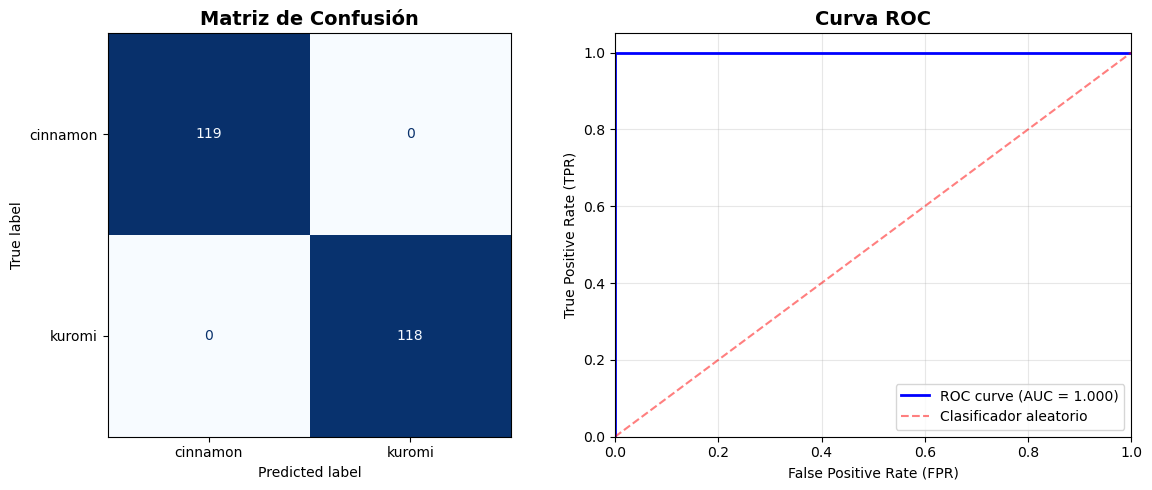

=== Métricas de Evaluación ===

  Accuracy:  100.00%
  Precisión: 100.00%
  Recall:    100.00%
  F1-Score:  100.00%
  AUC-ROC:   1.000

  Clase negativa (0): cinnamon
  Clase positiva (1): kuromi


In [9]:
# ============================================
# BLOQUE 11: Evaluación detallada
#
# ¿Qué hace: Pasa TODAS las imágenes de test por el modelo y calcula métricas. 
#   Muestra matriz de confusión, curva ROC, y tabla de métricas.
#
# ¿Por qué evaluar en test y no en train?
#   El modelo ya "vio" las imágenes de train. 
#   Evaluar ahi daria una medida optimista (sesgada).
#   Test contiene imágenes que el modelo JAMAS vio.
#
# ¿Variables clave:
#   - torch.softmax(outputs, dim=1): convierte las salidas "crudas" (logits) en probabilidades que suman 1. 
#     Ej: [0.2, 0.8] = 20% Kuromi, 80% Cinnamoroll.
#   - confusion_matrix(reales, predichas): matriz 2x2
#     donde:
#       [0,0] = Cinnamon clasificado bien
#       [0,1] = Cinnamon clasificado como Kuromi (error)
#       [1,0] = Kuromi clasificado como Cinnamon (error)
#       [1,1] = Kuromi clasificado bien
#   - roc_curve(reales, probabilidades): genera puntos para graficar TPR vs FPR a distintos umbrales.
#   - auc(fpr, tpr): área bajo la curva ROC.
#     AUC = 1.0 es clasificador perfecto.
#     AUC = 0.5 es aleatorio.
#
# ¿Por qué la clase positiva es la 1?
#   En clasificación binaria, "positivo" es lo que queremos detectar. 
#   Aqui elegimos Cinnamoroll como positiva (clase 1) porque... podria ser cualquiera. 
#   La curva ROC funciona igual.
#
# ¿Qué es la curva ROC?
#   Gráfica que muestra:
#   - Eje Y: TPR (True Positive Rate) = recall = que tan bien detectamos Cinnamoroll
#   - Eje X: FPR (False Positive Rate) = que tan seguido confundimos Kuromi como Cinnamoroll
#   - Linea diagonal: clasificador aleatorio
#   - Curva pegada a la esquina superior izquierda = perfecto
#
# ¿Para experimentar:
#   - Si AUC > 0.99, ¿qué más podemos pedir?
#   - Mira la matriz: ¿una clase tiene más errores que otra?
#   - Si precisión y recall son muy diferentes, hay
#     desbalance en los errores del modelo.
# ============================================

def evaluar_biclase(modelo, test_loader, device, clases):
    modelo.eval()
    todas_reales = []
    todas_predichas = []
    todas_probabilidades = []

    with torch.no_grad():
        for imágenes, etiquetas in test_loader:
            imágenes = imágenes.to(device)
            outputs = modelo(imágenes)
            probabilidades = torch.softmax(outputs, dim=1)  # [prob_clase0, prob_clase1]
            _, predichas = torch.max(outputs, 1)  # Indice de la clase con mayor prob

            todas_reales.extend(etiquetas.cpu().numpy())
            todas_predichas.extend(predichas.cpu().numpy())
            todas_probabilidades.extend(probabilidades[:, 1].cpu().numpy())  # Prob de clase 1 (Cinnamon)

    # ---- Matriz de confusión ----
    cm = confusion_matrix(todas_reales, todas_predichas)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
    disp.plot(ax=ax1, cmap='Blues', colorbar=False, values_format='d')
    ax1.set_title('Matriz de Confusión', fontsize=14, fontweight='bold')

    # ---- Curva ROC ----
    fpr, tpr, _ = roc_curve(todas_reales, todas_probabilidades)
    roc_auc = auc(fpr, tpr)

    ax2.plot(fpr, tpr, 'b-', linewidth=2,
             label='ROC curve (AUC = {:.3f})'.format(roc_auc))
    ax2.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Clasificador aleatorio')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('False Positive Rate (FPR)')
    ax2.set_ylabel('True Positive Rate (TPR)')
    ax2.set_title('Curva ROC', fontsize=14, fontweight='bold')
    ax2.legend(loc='lower right')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ---- Métricas numericas ----
    accuracy = 100.0 * (cm[0, 0] + cm[1, 1]) / cm.sum()
    # Precisión: de las que predije como positivas, cuántas lo eran?
    precisión = 100.0 * cm[1, 1] / (cm[1, 1] + cm[0, 1]) if (cm[1, 1] + cm[0, 1]) > 0 else 0
    # Recall: de las positivas reales, cuántas atrape?
    recall = 100.0 * cm[1, 1] / (cm[1, 1] + cm[1, 0]) if (cm[1, 1] + cm[1, 0]) > 0 else 0
    # F1: promedio armonico de precisión y recall
    f1 = 2 * precisión * recall / (precisión + recall) if (precisión + recall) > 0 else 0

    print('=== Métricas de Evaluación ===')
    print('')
    print('  Accuracy:  {:.2f}%'.format(accuracy))
    print('  Precisión: {:.2f}%'.format(precisión))
    print('  Recall:    {:.2f}%'.format(recall))
    print('  F1-Score:  {:.2f}%'.format(f1))
    print('  AUC-ROC:   {:.3f}'.format(roc_auc))
    print('')
    print('  Clase negativa (0): ' + clases[0])
    print('  Clase positiva (1): ' + clases[1])

evaluar_biclase(model, test_loader, device, clases)


---
## 11.5 ¿Leamos las métricas juntas?

### ¿Qué significan los números que acabamos de ver?

Usa esta guia para interpretar los resultados de la celda anterior:

#### Accuracy: [X]%
> Mide el porcentaje TOTAL de aciertos.
>
> **Ejemplo:** 99.16% = de 237 imágenes de test, solo 2 están mal.
>
> **¿Es bueno?** Si, excelente. Pero no nos dice DONDE fallo.
> Para eso esta la matriz de confusión.

#### Matriz de confusión
> |  | Predijo Cinnamoroll | Predijo Kuromi |
> |--|-------------------|---------------|
> | **Era Cinnamoroll** | ✅ Acierto | ❌ Falso negativo |
> | **Era Kuromi** | ❌ Falso positivo | ✅ Acierto |
>
> **¿Qué mirar?**
> - Los números en la diagonal (✅) deben ser ALTOS
> - Los números fuera de la diagonal (❌) deben ser CERO o casi
> - Si una clase tiene más errores que otra, hay un sesgo

#### Precisión: [X]%
> **Analogia del detector de spam:**
> De los correos que marque como spam, ¿cuántos eran spam realmente?
>
> **Aqui:** De las que dije "Cinnamoroll", ¿cuántas eran Cinnamoroll?
>
> **Alta precisión = pocos falsos positivos.** (No confundir Cinnamoroll con Kuromi)

#### Recall: [X]%
> **Analogia:** De todos los spams que llegaron, ¿cuántos atrape?
>
> **Aqui:** De todos los Cinnamoroll en test, ¿cuántos detecte?
>
> **Alto recall = pocos falsos negativos.** (No dejar pasar un Cinnamoroll sin detectar)

#### F1-Score: [X]%
> Promedio armonico de Precisión y Recall.
> Si uno es muy bajo, el F1 baja.
> Si ambos son altos, el F1 es alto.
>
> **¿Por qué armonico y no normal?**
> Porque el armonico penaliza más los valores bajos.
> Ej: precisión=100%, recall=50% -> F1=67% (justo).
> Con promedio normal sería 75% (demasiado optimista).

#### AUC-ROC: [X]
> Area bajo la curva ROC.
>
> | Valor | Significado |
> |-------|-------------|
> | 0.5 | Aleatorio (moneda al aire) |
> | 0.7-0.8 | Aceptable |
> | 0.8-0.9 | Bueno |
> | 0.9-0.95 | Muy bueno |
> | 0.95-0.99 | Excelente |
> | 1.0 | Perfecto |

### ¿Qué hacer si las métricas NO son buenas?

| Problema | Posible causa | Solución |
|----------|--------------|----------|
| Accuracy ~50% | El modelo no aprendio nada | Revisar si el dataset tiene las clases correctas |
| Precisión baja | Muchos falsos positivos | Aumentar datos de la clase que se confunde |
| Recall bajo | Muchos falsos negativos | Balancear clases o aumentar datos de esa clase |
| Train loss baja, Test loss sube | Overfitting | Mas dropout, menos épocas, más datos |
| AUC < 0.8 | El modelo no separa bien | Cambiar arquitectura o aumentar datos |


---
## 12. Viendo las predicciones con nuestros ojos

Las métricas son números fríos. Veamos las predicciones reales.

### ¿Qué muestra?

- **25 imágenes aleatorias** del test set 
- Cada una con su predicción: ✅ (acierto) o ❌ (error)
- Verde = correcto, Rojo = incorrecto
- El porcentaje de confianza

### ¿Por qué es importante?

A veces el modelo puede tener 99% de accuracy pero fallar
sistemáticamente en un tipo específico de imagen (ej: fondo rojo).
Las métricas no te muestran eso. Tus ojos sí.

> Es como en League: el KDA te dice que vas ganando la partida,
> pero no te dice contra quién sigues feedeando. Para eso
> tienes que ver el replay. Esta sección es nuestro replay.


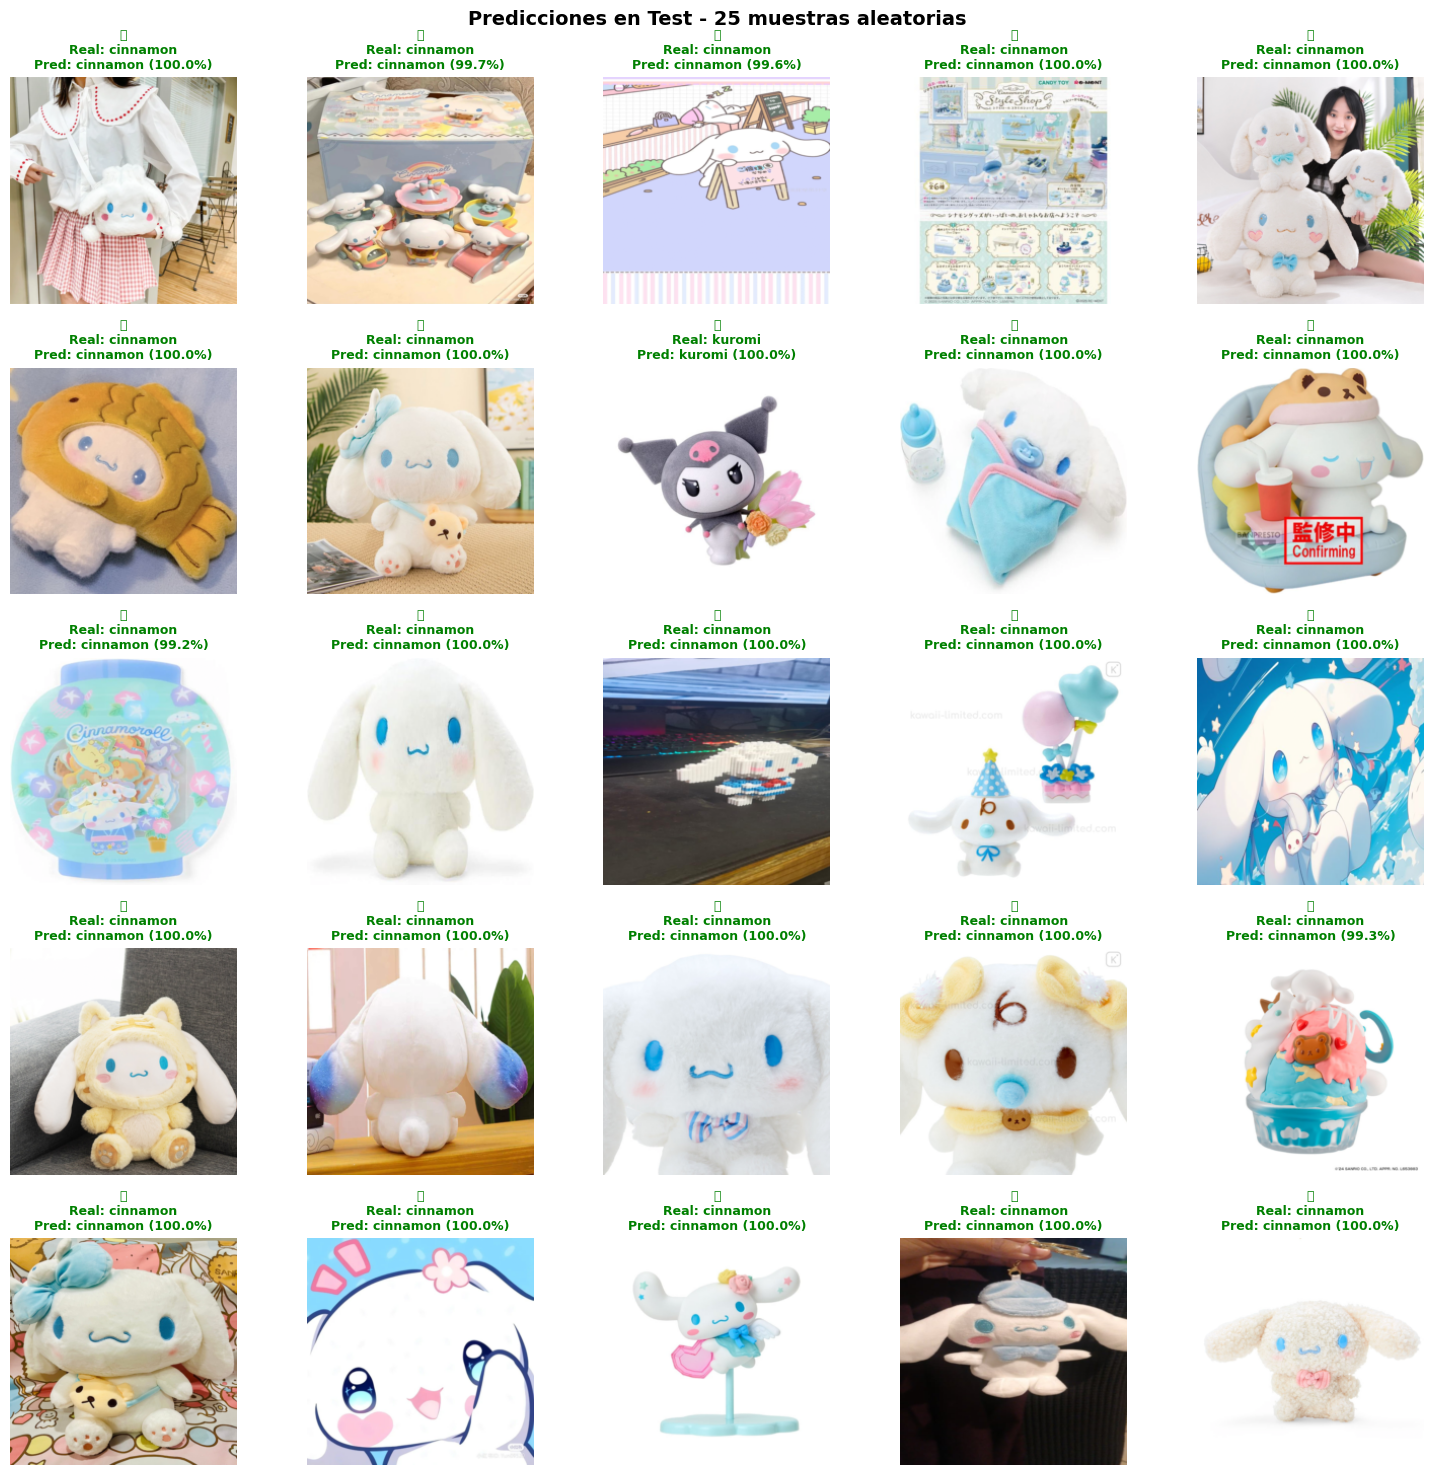

In [10]:
# ============================================
# BLOQUE 12: Grilla de predicciones
#
# ¿Qué hace: Toma 128 imágenes del test loader, guarda sus predicciones, y muestra 16 al azar con resultados en verde (acierto) o rojo (error).
#
# ¿Por qué 128 y no todas?
#   Mostrar 237 imágenes sería demasiado.
#   128 es una muestra representativa.
#   Luego seleccionamos 16 al azar.
#
# ¿Variables:
#   - imagenes_guardadas: lista de tuplas (imagen_tensor, etiqueta_real, predicha, confianza)
#   - desnormalizar: img * std + mean para ver colores reales
#   - torch.clamp(img, 0, 1): asegura que los valores esten en rango visible [0,1]
#   - .permute(1, 2, 0): cambia formato (C,H,W) a (H,W,C) porque matplotlib espera H,W,C
#
# ¿Por qué desnormalizar otra vez?
#   Las imágenes en el DataLoader están normalizadas (media=0, std=1).
#   Para MOSTRARLAS necesitamos revertir: multiplicar por std, sumar mean.
#   Si no, se ven verdes/azules (colores negativos).
#
# ¿Para experimentar:
#   - Cambia n=16 a n=25 para ver más ejemplos
#   - Si ves muchos errores, analiza el patrón:
#     ¿Son todas de un fondo similar? ¿Un ángulo?
#     Eso te dice QUE fotos tomar para mejorar.
# ============================================

import math
import random

model.eval()
imagenes_guardadas = []

with torch.no_grad():
    for imágenes, etiquetas in test_loader:
        imágenes, etiquetas = imágenes.to(device), etiquetas.to(device)
        salidas = model(imágenes)
        probabilidades = torch.softmax(salidas, dim=1)
        _, predichas = torch.max(salidas, 1)

        for i in range(len(imágenes)):
            if len(imagenes_guardadas) < 128:
                imagenes_guardadas.append((
                    imágenes[i].cpu(), etiquetas[i].item(),
                    predichas[i].item(), probabilidades[i, 1].item()
                ))

# Seleccionar 25 al azar 
n = 25
idx = random.sample(range(len(imagenes_guardadas)), n)

fig, axes = plt.subplots(5, 5, figsize=(15, 15))
for i, ax in enumerate(axes.flat):
    img, real, pred, prob = imagenes_guardadas[idx[i]]

    # Desnormalizar para visualizar (revertir Normalize)
    img = img * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) +           torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    img = torch.clamp(img, 0, 1)  # Recortar a rango visible

    ax.imshow(img.permute(1, 2, 0).numpy())
    acierto = real == pred
    color = 'green' if acierto else 'red'

    # Confianza: si predijo clase 1 (Cinnamon), prob es la confianza
    # Si predijo clase 0 (Kuromi), la confianza es 1 - prob
    conf = prob * 100 if pred == 1 else (1 - prob) * 100

    etiqueta = '{}\nReal: {}\nPred: {} ({:.1f}%)'.format(
        '✅' if acierto else '❌',
        clases[real], clases[pred], conf)
    ax.set_title(etiqueta, fontsize=9, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Predicciones en Test - 25 muestras aleatorias',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 13. ¿Dónde falla? Aprendiendo de los errores

Los errores son MAS valiosos que los aciertos porque
te dicen exactamente que mejorar.

### ¿Qué buscar en esta gráfica?

| Si el error es por... | Posible causa | Solución |
|----------------------|--------------|----------|
| Fondo raro | El modelo se confunde con el fondo | Tomar fotos con fondos variados |
| Ángulo extremo | El modelo no vio ese ángulo en train | Agregar fotos desde ese ángulo |
| Figura muy pequeña | El modelo no la distingue bien | Acercar la cámara |
| Iluminación extrema | Saturación de colores | Mejor iluminación o más aumentación |

> **Tip:** Si NO hay errores (festejo 🎉), ejecuta la celda
> de evaluación varias veces. Cada vez toma 128 muestras
> diferentes. Eventualmente aparecerá algún error.


In [11]:
# ============================================
# BLOQUE 13: Grilla de errores
#
# ¿Qué hace: De las 128 muestras guardadas, selecciona
#   SOLO las que el modelo clasificó MAL y las muestra.
#
# ¿Por qué? Los errores son más útiles que los aciertos
#   porque revelan las debilidades del modelo.
#
# ¿Variables:
#   - errores: lista de tuplas filtrada (solo real != pred)
#   - n_mostrar: cuántos errores mostrar (max 12)
#   - Si len(errores) == 0: !no hubo errores en la muestra!
#     (significa que el modelo es muy bueno o que la muestra tenía suerte: ejecuta de nuevo para confirmar)
#
# ¿Para experimentar:
#   - Si ves errores recurrentes (ej: siempre con fondo rojo), toma fotos de esa figura con otro fondo.
#   - Si el error es siempre la misma figura (mod7, mod8), significa que esa figura es muy diferente a las de train. 
#     - Agrégala a train en vez de test.
# ============================================

errores = [(img, real, pred, prob) for (img, real, pred, prob) in imagenes_guardadas
           if real != pred]

if len(errores) == 0:
    print('\n? No hubo errores en las 128 muestras guardadas! 🎉')
else:
    n_mostrar = min(len(errores), 12)
    cols = 4
    rows = math.ceil(n_mostrar / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
    axes = np.array(axes).ravel()

    for i in range(n_mostrar):
        img, real, pred, prob = errores[i]
        img = img * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        img = torch.clamp(img, 0, 1)
        axes[i].imshow(img.permute(1, 2, 0).numpy())
        axes[i].set_title('Real: {}\nPred: {} ({:.1f}%)'.format(
            clases[real], clases[pred],
            prob * 100 if pred == 1 else (1 - prob) * 100),
            fontsize=9, color='red')
        axes[i].axis('off')

    for i in range(n_mostrar, len(axes)):
        axes[i].axis('off')

    plt.suptitle('Errores del Modelo en Test ({} errores de 128 muestras)'.format(
        len(errores)), fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('\nTasa de error en estas 128 muestras: {:.1f}%'.format(
        len(errores) / len(imagenes_guardadas) * 100))



? No hubo errores en las 128 muestras guardadas! 🎉


---
## 13.5 ¿Y en qué se fijó el modelo? (Grad-CAM)

### Una duda válida: ¿de verdad necesitamos saber esto?

Tal cual, no nos sirve para que el modelo aprenda mejor matemáticamente.
Eso ya lo resuelve el optimizador solito. Pero sí nos sirve para algo
más importante antes de subir esto a producción: **confiar (o no)**
en lo que el modelo está haciendo.

### ¿Qué es Grad-CAM?

Es como pedirle al modelo que nos preste sus lentes un segundo.
Genera un mapa de calor sobre la imagen original: las zonas en
rojo/amarillo son donde la red "miró más fuerte" para tomar su
decisión, y las zonas en azul/morado las prácticamente ignoró.

> Analogía: Imagina que le preguntas a alguien "¿cómo supiste que
> era Kuromi y no Cinnamoroll?" y en vez de explicarlo con palabras,
> te señala con el dedo: "por las orejotas negras y la calavera rosa".
> Eso es exactamente lo que hace Grad-CAM, pero señalando con calor
> en vez de con el dedo.

### ¿Por qué sí vale la pena aquí?

- **Detectar trampas:** si el modelo se está fijando en el fondo
  (ej: porque todas tus fotos de Kuromi las tomaste en tu cuarto y
  las de Cinnamoroll en la sala), Grad-CAM lo delata. Sin esto,
  jamás te enterarías de que tu 99% de accuracy es trampa.
- **Confianza para producción:** cuando subas esto a una página web,
  poder mostrar "así es como decidí" es mucho más profesional que
  solo escupir un porcentaje de la nada.
- **No es rebuscado:** es de las técnicas de interpretabilidad más
  usadas en la industria real (por ejemplo en radiología, para
  verificar que el modelo mira el tumor y no una marca de la
  máquina de rayos X).

### ¿Qué SÍ vamos a poder concluir con esto?

Que el modelo se fija en orejas, calavera/capucha y forma general
de la cabeza (las partes que tú y yo también usaríamos para
distinguirlas). Eso es justo lo que queremos ver: que aprendió
las figuras, no trucos del dataset.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.004313725512474775..1.000000011920929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.00862745102494955..1.000000011920929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1747058928012848..1.000000011920929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.3256863057613373..1.000000011920929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.004313725512474775..1.000000011920929].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.03019607812166214..1.000000011920929].


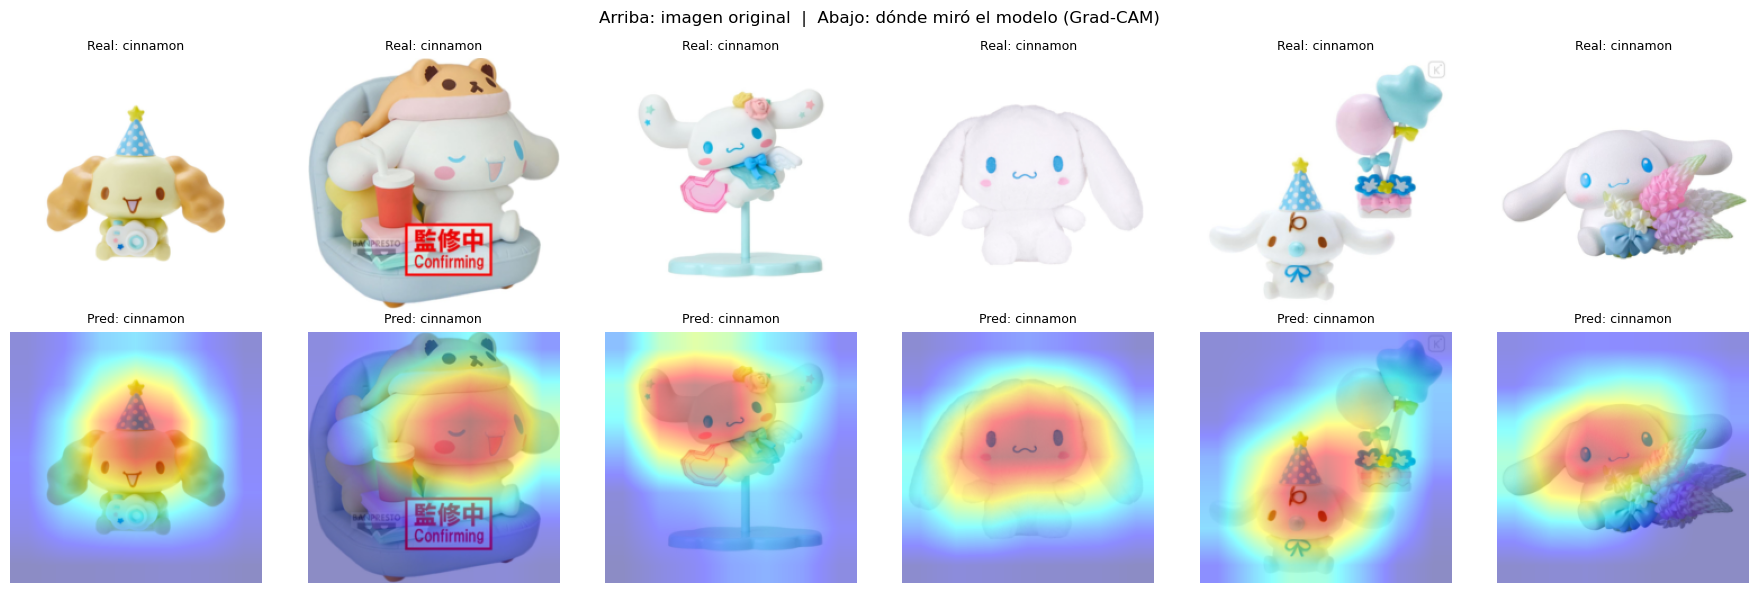

In [12]:
# ============================================
# BLOQUE 13.5: Grad-CAM (mapas de calor)
#
# ¿Qué hace: Calcula, para una imagen, qué pixeles influyeron más en la decisión final de la red, usando los gradientes de la última capa convolucional (layer4 de ResNet18).
#
# ¿Cómo funciona (intuición, no la matemática completa):
#   1. Hacemos un forward pass normal hasta layer4.
#   2. Calculamos el gradiente de la clase predicha respecto a esos mapas de activación.
#   3. Promediamos esos gradientes por canal -> nos dice qué tan importante fue cada canal (filtro).
#   4. Ponderamos los mapas de activación con esa importancia y aplicamos ReLU (solo nos interesa lo que ayudó, no lo que estorbó).
#   5. Redimensionamos ese mapa pequeño (7x7) a 224x224 y lo sobreponemos como mapa de calor.
#
# ¿Variables clave:
#   - activaciones / gradientes: capturados con hooks de PyTorch
#   - capa_objetivo: layer4 (la última conv antes del pooling), porque ahí todavía hay info espacial (7x7), ya en el vector final esa info se perdió.
# ============================================

import cv2

activaciones = {}
gradientes = {}

def hook_forward(module, input, output):
    activaciones['valor'] = output.detach()

def hook_backward(module, grad_input, grad_output):
    gradientes['valor'] = grad_output[0].detach()

capa_objetivo = model.layer4[-1]
h1 = capa_objetivo.register_forward_hook(hook_forward)
h2 = capa_objetivo.register_full_backward_hook(hook_backward)

def generar_gradcam(img_tensor, clase_objetivo=None):
    model.eval()
    img_tensor = img_tensor.unsqueeze(0).to(device)
    img_tensor.requires_grad_()

    salida = model(img_tensor)
    if clase_objetivo is None:
        clase_objetivo = salida.argmax(dim=1).item()

    model.zero_grad()
    salida[0, clase_objetivo].backward()

    acts = activaciones['valor'][0]      # (C, 7, 7)
    grads = gradientes['valor'][0]       # (C, 7, 7)

    pesos = grads.mean(dim=(1, 2))       # importancia por canal
    mapa = torch.zeros(acts.shape[1:], dtype=torch.float32).to(device)
    for i, peso in enumerate(pesos):
        mapa += peso * acts[i]

    mapa = torch.relu(mapa).cpu().numpy()
    mapa = cv2.resize(mapa, (224, 224))
    mapa = (mapa - mapa.min()) / (mapa.max() - mapa.min() + 1e-8)
    return mapa, clase_objetivo

# --- Visualizar Grad-CAM en varios ejemplos del test set ---
model.eval()
imagenes_muestra, etiquetas_muestra = next(iter(test_loader))

n_ejemplos = min(6, len(imagenes_muestra))
fig, axes = plt.subplots(2, n_ejemplos, figsize=(n_ejemplos * 3, 6))

mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

for i in range(n_ejemplos):
    img_tensor = imagenes_muestra[i]
    mapa, clase_pred = generar_gradcam(img_tensor)

    img_mostrar = img_tensor * std[:, None, None] + mean[:, None, None]
    img_mostrar = torch.clamp(img_mostrar, 0, 1).permute(1, 2, 0).numpy()

    heatmap = (mapa * 255).astype('uint8')
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
    superpuesta = 0.55 * img_mostrar + 0.45 * heatmap_color

    nombre_clase = train_dataset.classes[clase_pred]
    real = train_dataset.classes[etiquetas_muestra[i].item()]

    axes[0, i].imshow(img_mostrar)
    axes[0, i].set_title('Real: ' + real, fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(superpuesta)
    axes[1, i].set_title('Pred: ' + nombre_clase, fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('Arriba: imagen original  |  Abajo: dónde miró el modelo (Grad-CAM)')
plt.tight_layout()
plt.show()

h1.remove()
h2.remove()


### ¿Qué observar en los mapas de calor?

- Si lo rojo/amarillo cae sobre la **cara, orejas o capucha** de la
  figura: el modelo aprendió lo correcto. ✅
- Si lo rojo cae sobre el **fondo, la mesa o un dedo en la foto**:
  mala señal, hay que revisar el dataset (puede que estés
  fotografiando siempre en el mismo lugar). 🚩
- Es normal que en los errores el mapa de calor se vea "confundido"
  o disperso, en vez de concentrado en una sola zona; eso es justo
  el modelo "dudando" visualmente, igual que dudaría una persona.


---
## 14. Probando con tus propias fotos

Ahora la parte divertida: sube una foto de UNA figura
y el modelo te dice si es Kuromi o Cinnamoroll.

### Cómo funciona

1. Cargamos la imagen (desde archivo)
2. La redimensionamos a 224x224
3. La normalizamos (con los mismos valores de ImageNet)
4. La pasamos por el modelo
5. El modelo devuelve: "70% Kuromi, 30% Cinnamoroll"
6. Mostramos la imagen con su predicción y barra de confianza

### ¿Qué fotos probar?

| Tipo de foto | ¿Qué esperar? |
|-------------|--------------|
| Figura de train | Debe clasificar bien (ya la vio) |
| Figura de test | Debe clasificar bien (no la vio, pero es similar) |
| Figura NUNCA vista | La verdadera prueba de generalización |
| Foto de internet | Depende de que tan parecida sea a las del dataset |
| Objeto que NO es Sanrio | Va a clasificar como algo (siempre da una respuesta) |


In [13]:
# ============================================
# BLOQUE 14: Función de predicción
#
# ¿Qué hace: Toma una imagen (archivo o PIL.Image), la preprocesa, la pasa por el modelo, y muestra el resultado con grafico.
#
# ¿Variables:
#   - transform: mismas transformaciones que test (sin aumentación, solo resize + normalizar)
#   - .unsqueeze(0): agrega dimensión de batch Porque el modelo espera (batch, C, H, W) pero una sola imagen es (C, H, W).
#     unsqueeze(0) la convierte en (1, C, H, W).
#   - torch.softmax: probabilidades que suman 1
#   - np.argsort(prob)[::-1]: indices ordenados de mayor a menor probabilidad
#
# ¿Por qué top=2?
#   Tenemos 2 clases, mostrar las 2 es lo lógico.
#   Si en el futuro agregas más clases, cambia top=3.
#
# ¿Qué esperar de la gráfica?
#   Izquierda: la imagen con la predicción principal.
#   Derecha: barras con la probabilidad de cada clase.
#   Si una barra es mucho más alta, el modelo esta seguro. 
#   Si las dos son similares (~50-50), el modelo no esta seguro (imagen borderline).
#
# ¿Por qué confianza > 70% es verde?
#   Si el modelo tiene >70% de confianza, es una predicción solida.
#   Entre 50-70% es dudosa (naranja). <50% es contradictorio (pero no deberia pasar con 2 clases, ya que suman 100).
#
# ¿Para experimentar:
#   - Prueba con una foto de Hello Kitty u otro personaje.
#     ¿Qué predice? ¿Con que confianza?
#   - Prueba con una foto de un objeto cualquiera (tu mano, tu telefono).
#     El modelo siempre va a clasificar como uno de los dos, porque solo sabe de 2 clases.
#     La confianza sera baja (~50-60%).
# ============================================

def predecir_figura(ruta_imagen, modelo, device, clases, top=2):
    modelo.eval()

    # Cargar imagen
    if isinstance(ruta_imagen, str):
        imagen = Image.open(ruta_imagen).convert('RGB')
    else:
        imagen = ruta_imagen.convert('RGB')

    # Preprocesar (igual que en test)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    tensor = transform(imagen).unsqueeze(0).to(device)  # (1, 3, 224, 224)

    # Predecir
    with torch.no_grad():
        outputs = modelo(tensor)
        probabilidades = torch.softmax(outputs, dim=1)[0]

    # Top predicciones
    prob_np = probabilidades.cpu().numpy()
    indices_top = np.argsort(prob_np)[::-1][:top]

    # Grafico
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

    ax1.imshow(imagen)
    ax1.axis('off')

    pred_idx = indices_top[0]
    pred_clase = clases[pred_idx]
    confianza = prob_np[pred_idx] * 100
    color = 'green' if confianza > 70 else 'orange'

    ax1.set_title('Predicción: {}\nConfianza: {:.1f}%'.format(pred_clase, confianza),
                  fontsize=14, fontweight='bold', color=color)

    # Barras de probabilidad
    colores_barras = ['steelblue'] * len(clases)
    colores_barras[pred_idx] = 'crimson'
    ax2.barh(clases, prob_np, color=colores_barras, edgecolor='gray')
    ax2.set_xlim(0, 1)
    ax2.set_xlabel('Probabilidad')
    ax2.set_title('Distribución de probabilidad')
    ax2.grid(axis='x', alpha=0.3)

    for i, v in enumerate(prob_np):
        ax2.text(v + 0.01, i, '{:.1%}'.format(v), va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    return pred_clase, confianza


---
## 15. Probar el modelo

Selecciona una imagen de una figura de Kuromi o Cinnamoroll
y el modelo te dira que es.


In [ ]:
# ---
# Colab: subir imagen
# ---
if EN_COLAB:
    print('Sube una foto de una figura de Kuromi o Cinnamoroll...')
    archivos = files.upload()
    if archivos:
        nombre = list(archivos.keys())[0]
        img = Image.open(io.BytesIO(archivos[nombre]))
        predecir_figura(img, model, device, clases)
    else:
        print('No se subio ninguna imagen.')
else:
    print('Usa la siguiente celda para VSCode.')


Usa la siguiente celda para VSCode.


: 

In [ ]:
# ---
# VSCode: seleccionar archivo local
# ---
if not EN_COLAB:
    from tkinter import filedialog, Tk
    root = Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    ruta = filedialog.askopenfilename(
        title='Selecciona una foto de Kuromi o Cinnamoroll',
        filetypes=[('Imágenes', '*.png *.jpg *.jpeg *.bmp')]
    )

    if ruta:
        resultado, confianza = predecir_figura(ruta, model, device, clases)
        print('Resultado: {} (Confianza: {:.1f}%)'.format(resultado, confianza))
    else:
        print('No se selecciono ninguna imagen.')
else:
    print('Usa la celda anterior (Colab).')


---
## 16. Guardando el modelo

Guardamos el modelo entrenado para usarlo despues sin
tener que volver a entrenar.

### ¿Qué se guarda exactamente?

- **modelo_final.pth**: los pesos de las neuronas (state_dict)
  ~45 MB (el modelo completo, no las imágenes)
- **clases.json**: el mapeo clase -> indice
- **log_[fecha].csv**: la historia del entrenamiento
  (loss y accuracy por época)

### ¿Cómo lo cargo despues?

```python
# Crear misma arquitectura (usando la misma función)
modelo = crear_modelo_transfer_learning(num_clases=2, congelar=False)
# Cargar pesos guardados
modelo.load_state_dict(torch.load('modelos/modelo_final.pth'))
modelo.eval()
```

> **Importante:** Al cargar, usa `congelar=False` para que
> TODOS los pesos tengan `requires_grad=True` y el
> state_dict coincida con la arquitectura.


In [ ]:
# ============================================
# BLOQUE 16: Guardar modelo y log
#
# ¿Qué se guarda?
#   - modelo_[timestamp].pth: versión con fecha/hora
#   - modelo_final.pth: siempre sobrescribe (fácil de cargar)
#   - clases.json: mapeo para saber que indice corresponde a que clase
#   - log_[timestamp].csv: tabla con loss y accuracy por época para importar a Excel y graficar
#
# ¿Por qué 2 versiones del modelo?
#   - Versión con timestamp: historico, no se pierde
#   - Versión "final": siempre apunta al ultimo, fácil de referenciar en scripts
#
# ¿Qué es el state_dict?
#   Un diccionario Python que mapea:
#   'layer1.0.conv1.weight' -> tensor de pesos
#   'fc.0.weight' -> pesos de la cabeza nueva
#   ...
#   Es el "cerebro" del modelo. Sin el, el modelo no sabe nada.
#
# ¿Para experimentar:
#   - Abre clases.json con un editor de texto
#   - Abre el .csv en Excel y gráfica loss vs accuracy
#   - Carga modelo_final.pth en un script aparte para hacer predicciones sin el notebook
# ============================================

from datetime import datetime

timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

# Versión con timestamp (no se pierde)
ruta_modelo_vers = os.path.join(RUTA_MODELOS, 'modelo_{}.pth'.format(timestamp))
torch.save(model.state_dict(), ruta_modelo_vers)

# Versión sin timestamp (siempre sobrescribe, fácil de cargar)
ruta_modelo_final = os.path.join(RUTA_MODELOS, 'modelo_final.pth')
torch.save(model.state_dict(), ruta_modelo_final)

tamano_kb = os.path.getsize(ruta_modelo_final) / 1024.0
print('Modelo versionado:', ruta_modelo_vers)
print('Modelo final:', ruta_modelo_final)
print('Tamano: {:.1f} KB'.format(tamano_kb))

# Guardar mapeo de clases
with open(os.path.join(RUTA_MODELOS, 'clases.json'), 'w') as f:
    json.dump({
        'classes': clases,
        'class_to_idx': train_dataset.class_to_idx,
        'fecha': timestamp,
        'autora': AUTORA
    }, f, indent=2)
print('Mapeo de clases guardado.')

# Guardar log de entrenamiento como CSV
import csv
ruta_log = os.path.join(RUTA_MODELOS, 'log_entrenamiento_{}.csv'.format(timestamp))
with open(ruta_log, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch', 'train_loss', 'test_loss', 'test_acc'])
    for i in range(len(historial['train_loss'])):
        writer.writerow([
            i+1,
            '{:.4f}'.format(historial['train_loss'][i]),
            '{:.4f}'.format(historial['test_loss'][i]),
            '{:.2f}'.format(historial['test_acc'][i])
        ])
print('Log de entrenamiento:', ruta_log)


Modelo versionado: d:\Diplomado-RNA\Modulo-4\Proyectos\Kuromi_vs_Cinnamoroll\modelos\modelo_2026-06-21_10-46-34.pth
Modelo final: d:\Diplomado-RNA\Modulo-4\Proyectos\Kuromi_vs_Cinnamoroll\modelos\modelo_final.pth
Tamano: 44251.6 KB
Mapeo de clases guardado.
Log de entrenamiento: d:\Diplomado-RNA\Modulo-4\Proyectos\Kuromi_vs_Cinnamoroll\modelos\log_entrenamiento_2026-06-21_10-46-34.csv


---
## 17. ¿Cómo mejorar el modelo?

### ¿Podemos seguir entrenando?

**Si.** Puedes cargar el modelo guardado y seguir entrenando
(solo cambia num_epochs). Pero ojo:

> Si el modelo ya llego a 99%+ de accuracy, seguir entrenando
> probablemente NO mejorara (peor, podria overfittear).

### ¿Mejor empezar de nuevo o seguir?

| Situación | Recomendación |
|-----------|--------------|
| Agregaste 50 fotos nuevas | **Seguir entrenando** desde el checkpoint |
| Cambiaste hiperparametros | **Empezar de nuevo** (el checkpoint tiene los viejos) |
| Cambiaste de ResNet18 a ResNet34 | **Empezar de nuevo** (arquitectura diferente) |
| Solo quieres ver si mejora | **Seguir entrenando** por 5-10 épocas más |

### ¿Cómo cargar un modelo guardado para seguir entrenando?

```python
# En la sección 6, despues de crear el modelo:
modelo.load_state_dict(torch.load('modelos/modelo_final.pth'))
# Luego continua con la sección 7, 8, 9...
# El entrenamiento continuara desde donde lo dejaste.
```

### ¿Y si queremos probar otro modelo?

Cambia SOLO una línea en la sección 6:

```python
# Para ResNet34:
modelo = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)

# Para ResNet50:
modelo = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Para EfficientNet:
modelo = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
```

Y ajusta el número de features:
```python
# Para ResNet34/50: in_features=512 (igual que ResNet18)
# Para EfficientNet: in_features=1280
num_features = modelo.classifier[1].in_features  # EfficientNet
```

### ¿Vale la pena probar otro modelo?

| Si quieres... | Prueba... | Por qué |
|--------------|-----------|---------|
| Mas precisión | ResNet34 | 2x parametros, 12 min, mejora marginal |
| Mas velocidad | EfficientNet-B0 | Menos parametros, misma precisión |
| Estado del arte | ResNet50 | Solo si tienes 5000+ imágenes |
| App movil/embedded | MobileNetV3 | Lo veras en Módulo 5 (TinyML) |


---
## 17.5 Experimentos: Exploración de Hiperparametros

### Por qué experimentar?

En nuestra configuración usamos valores "default": batch_size=16,
lr=0.001, dropout=0.3. Pero... son los mejores para nuestro dataset?

Vamos a probar otras combinaciones y comparar resultados.

### Qué vamos a probar

| Experimento | Cambio | Qué esperar |
|-------------|--------|-------------|
| **baseline** | batch_size=16, lr=0.001, dropout=0.3 | Referencia (los valores que ya conocemos) |
| **batch_size=32** | El doble de imágenes por lote | Entrenamiento más rápido, gradientes menos precisos |
| **lr=0.01** | Learning rate 10x mayor | Podria converger más rápido... o diverger |
| **lr=0.0001** | Learning rate 10x menor | Mas lento, pero más estable |
| **dropout=0.5** | Apagar la mitad de neuronas | Mas regularización, menos overfitting |

### Cómo leer los resultados

Cada experimento entrena solo Fase 1 por 5 épocas para ser rápido.
Suficiente para ver tendencias ~2-3 min cada uno en RTX 4060.

> **Tip:** Corre los experimentos de uno en uno.
> La tabla de comparación al final solo muestra los que ejecutaste.


In [ ]:
# ============================================
# BLOQUE 17.5a: Helper para experimentos
#
# ¿Qué hace: Define una función reutilizable que entrena un modelo con config modificada.
#   Cada experimento usa variables INDEPENDIENTES para no contaminar el modelo principal.
#
# ¿Variables:
#   - RESULTADOS_HIPER (dict): acumula resultados de todos los experimentos que ejecutes.
#     Cada entrada: nombre -> {accuracy, test_loss, config}
#   - experimento_hiperparametros(): función que:
#     1. Copia CONFIG y aplica cambios
#     2. Crea NUEVO DataLoader si cambio batch_size
#     3. Crea NUEVO modelo (pesos de ImageNet)
#     4. Entrena solo Fase 1 (rápido)
#     5. Guarda resultado en RESULTADOS_HIPER
#     6. Retorna el mejor accuracy
#
# ¿Por qué solo Fase 1?
#   La Fase 2 toma ~8 min adicionales. Para comparar hiperparametros, la Fase 1 ya muestra diferencias.
#   Si un hiperparametro funciona mal en Fase 1, no va a mejorar en Fase 2.
#
# ¿Por qué crear modelo NUEVO cada vez?
#   Si reusaramos el mismo modelo, los experimentos no serian independientes.
#   El modelo "recordaria" cosas del experimento anterior.
#
# ¿Para experimentar:
#   - Cambia épocas=5 a épocas=10 para resultados más precisos (tardara el doble)
#   - Agrega tu propio experimento con {'LR_FASE2': 0.0005} para probar fine-tuning
# ============================================

RESULTADOS_HIPER = {}

def experimento_hiperparametros(nombre, config_overrides, épocas=5):
    print('\n' + '=' * 60)
    print('  EXPERIMENTO: ' + nombre)
    print('  Cambios: ' + str(config_overrides))
    print('=' * 60)

    # 1. Copiar CONFIG y aplicar cambios
    cfg = CONFIG.copy()
    cfg.update(config_overrides)

    # 2. DataLoaders con nuevo batch_size (si cambio)
    bs = cfg['BATCH_SIZE']
    train_loader_exp = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    test_loader_exp = DataLoader(test_dataset, batch_size=bs, shuffle=False)

    # 3. Crear modelo NUEVO para este experimento
    model_exp = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for param in model_exp.parameters():
        param.requires_grad = False
    model_exp.fc = nn.Sequential(
        nn.Dropout(cfg['DROPOUT']),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, 2)
    )
    model_exp = model_exp.to(device)

    # 4. Optimizador y scheduler
    optimizer_exp = optim.Adam(
        filter(lambda p: p.requires_grad, model_exp.parameters()),
        lr=cfg['LR_FASE1']
    )
    scheduler_exp = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_exp, mode='min', factor=0.5, patience=3
    )
    criterion_exp = nn.CrossEntropyLoss()

    # 5. Entrenar (solo Fase 1 por rapidez)
    historial_exp = entrenar_biclase(
        model_exp, train_loader_exp, test_loader_exp, criterion_exp,
        optimizer_exp, scheduler_exp, num_epochs=épocas,
        device=device, nombre_fase='Exp: ' + nombre
    )

    mejor_acc = max(historial_exp['test_acc'])
    test_loss_final = historial_exp['test_loss'][-1]

    # 6. Guardar resultado
    RESULTADOS_HIPER[nombre] = {
        'accuracy': mejor_acc,
        'test_loss': test_loss_final,
        'config': config_overrides
    }

    print('  Resultado: Accuracy = {:.2f}%  Loss = {:.4f}'.format(mejor_acc, test_loss_final))
    return mejor_acc


In [ ]:
# --- Experimento: Baseline (valores originales) ---
# batch_size=16, lr=0.001, dropout=0.3
# Sirve como referencia para comparar los demas experimentos.
acc_baseline = experimento_hiperparametros(
    'baseline',
    {'BATCH_SIZE': 16, 'LR_FASE1': 0.001, 'DROPOUT': 0.3},
    épocas=5
)



  EXPERIMENTO: baseline
  Cambios: {'BATCH_SIZE': 16, 'LR_FASE1': 0.001, 'DROPOUT': 0.3}
Exp: baseline [ 1/5]  Train Loss: 0.4209  Test Loss: 0.1747  Acc: 94.94%  LR: 0.001000
Exp: baseline [ 2/5]  Train Loss: 0.2084  Test Loss: 0.2137  Acc: 90.72%  LR: 0.001000
Exp: baseline [ 3/5]  Train Loss: 0.2873  Test Loss: 0.1491  Acc: 94.51%  LR: 0.001000
Exp: baseline [ 4/5]  Train Loss: 0.2851  Test Loss: 0.1410  Acc: 95.36%  LR: 0.001000
Exp: baseline [ 5/5]  Train Loss: 0.2516  Test Loss: 0.1353  Acc: 94.94%  LR: 0.001000
Exp: baseline completada. Mejor accuracy: 95.36%
  Resultado: Accuracy = 95.36%  Loss = 0.1353


In [ ]:
# --- Experimento: batch_size=32 ---
# El doble de imágenes por lote.
# ¿Qué esperar?: Entrenamiento más rápido (menos iteraciones por época)
# pero posiblemente menor accuracy porque los gradientes promedian sobre más imágenes y son menos precisos.
# Si cabe en VRAM sin OOM, deberia funcionar bien.
acc_bs32 = experimento_hiperparametros(
    'batch_size=32',
    {'BATCH_SIZE': 32, 'LR_FASE1': 0.001, 'DROPOUT': 0.3},
    épocas=5
)



  EXPERIMENTO: batch_size=32
  Cambios: {'BATCH_SIZE': 32, 'LR_FASE1': 0.001, 'DROPOUT': 0.3}
Exp: batch_size=32 [ 1/5]  Train Loss: 0.4662  Test Loss: 0.3255  Acc: 82.28%  LR: 0.001000
Exp: batch_size=32 [ 2/5]  Train Loss: 0.3185  Test Loss: 0.1673  Acc: 94.09%  LR: 0.001000
Exp: batch_size=32 [ 3/5]  Train Loss: 0.2068  Test Loss: 0.1408  Acc: 95.36%  LR: 0.001000
Exp: batch_size=32 [ 4/5]  Train Loss: 0.1898  Test Loss: 0.1899  Acc: 93.67%  LR: 0.001000
Exp: batch_size=32 [ 5/5]  Train Loss: 0.2290  Test Loss: 0.1572  Acc: 92.41%  LR: 0.001000
Exp: batch_size=32 completada. Mejor accuracy: 95.36%
  Resultado: Accuracy = 95.36%  Loss = 0.1572


In [ ]:
# --- Experimento: learning rate = 0.01 ---
# Learning rate 10x mayor (más agresivo).
# ¿Qué esperar?: El modelo puede aprender más rápido... o diverger.
# Si la loss SUBE en vez de bajar, el LR es demasiado alto.
# Es el experimento más riesgoso, pero a veces da sorpresas.
acc_lr01 = experimento_hiperparametros(
    'lr=0.01',
    {'BATCH_SIZE': 16, 'LR_FASE1': 0.01, 'DROPOUT': 0.3},
    épocas=5
)



  EXPERIMENTO: lr=0.01
  Cambios: {'BATCH_SIZE': 16, 'LR_FASE1': 0.01, 'DROPOUT': 0.3}
Exp: lr=0.01 [ 1/5]  Train Loss: 0.7903  Test Loss: 0.4643  Acc: 71.31%  LR: 0.010000
Exp: lr=0.01 [ 2/5]  Train Loss: 0.3468  Test Loss: 0.1481  Acc: 95.78%  LR: 0.010000
Exp: lr=0.01 [ 3/5]  Train Loss: 0.2728  Test Loss: 0.1431  Acc: 93.67%  LR: 0.010000
Exp: lr=0.01 [ 4/5]  Train Loss: 0.2925  Test Loss: 0.1363  Acc: 93.25%  LR: 0.010000
Exp: lr=0.01 [ 5/5]  Train Loss: 0.2619  Test Loss: 0.2272  Acc: 87.34%  LR: 0.010000
Exp: lr=0.01 completada. Mejor accuracy: 95.78%
  Resultado: Accuracy = 95.78%  Loss = 0.2272


In [ ]:
# --- Experimento: learning rate = 0.0001 ---
# Learning rate 10x menor (más conservador).
# ¿Qué esperar?: El modelo aprende más lento y estable.
# Puede que necesite MAS épocas para alcanzar el mismo accuracy que baseline. 
# Pero llegado el momento, podria superarlo porque hace ajustes más finos.
acc_lr0001 = experimento_hiperparametros(
    'lr=0.0001',
    {'BATCH_SIZE': 16, 'LR_FASE1': 0.0001, 'DROPOUT': 0.3},
    épocas=5
)



  EXPERIMENTO: lr=0.0001
  Cambios: {'BATCH_SIZE': 16, 'LR_FASE1': 0.0001, 'DROPOUT': 0.3}
Exp: lr=0.0001 [ 1/5]  Train Loss: 0.5801  Test Loss: 0.4503  Acc: 90.72%  LR: 0.000100
Exp: lr=0.0001 [ 2/5]  Train Loss: 0.4299  Test Loss: 0.3224  Acc: 94.94%  LR: 0.000100
Exp: lr=0.0001 [ 3/5]  Train Loss: 0.3432  Test Loss: 0.2568  Acc: 94.09%  LR: 0.000100
Exp: lr=0.0001 [ 4/5]  Train Loss: 0.2930  Test Loss: 0.2066  Acc: 96.20%  LR: 0.000100
Exp: lr=0.0001 [ 5/5]  Train Loss: 0.2815  Test Loss: 0.1879  Acc: 96.20%  LR: 0.000100
Exp: lr=0.0001 completada. Mejor accuracy: 96.20%
  Resultado: Accuracy = 96.20%  Loss = 0.1879


In [ ]:
# --- Experimento: dropout = 0.5 ---
# Apagamos la mitad de las neuronas al azar.
# ¿Qué esperar?: Mas regularización = menos overfitting.
# Pero como hay menos "capacidad" disponible, puede tardar más en aprender.
# Ideal para datasets pequeños donde el riesgo de overfitting es alto.
acc_drop05 = experimento_hiperparametros(
    'dropout=0.5',
    {'BATCH_SIZE': 16, 'LR_FASE1': 0.001, 'DROPOUT': 0.5},
    épocas=5
)



  EXPERIMENTO: dropout=0.5
  Cambios: {'BATCH_SIZE': 16, 'LR_FASE1': 0.001, 'DROPOUT': 0.5}
Exp: dropout=0.5 [ 1/5]  Train Loss: 0.4610  Test Loss: 0.2472  Acc: 91.56%  LR: 0.001000
Exp: dropout=0.5 [ 2/5]  Train Loss: 0.3202  Test Loss: 0.1823  Acc: 93.25%  LR: 0.001000
Exp: dropout=0.5 [ 3/5]  Train Loss: 0.2822  Test Loss: 0.1509  Acc: 94.94%  LR: 0.001000
Exp: dropout=0.5 [ 4/5]  Train Loss: 0.2995  Test Loss: 0.1850  Acc: 92.83%  LR: 0.001000
Exp: dropout=0.5 [ 5/5]  Train Loss: 0.3560  Test Loss: 0.3607  Acc: 80.17%  LR: 0.001000
Exp: dropout=0.5 completada. Mejor accuracy: 94.94%
  Resultado: Accuracy = 94.94%  Loss = 0.3607


In [ ]:
# --- Tabla comparativa de hiperparametros ---
# Muestra los resultados de todos los experimentos ejecutados.
# NOTA: Si no corriste algún experimento, no aparecerá.

if RESULTADOS_HIPER:
    print('\n' + '=' * 60)
    print('  COMPARACION DE HIPERPARAMETROS')
    print('=' * 60)
    print('  {:<20s}  {:>10s}  {:>10s}  {:>10s}'.format(
        'Experimento', 'Accuracy', 'Test Loss', 'vs Baseline'))
    print('  ' + '-' * 55)

    baseline_acc = RESULTADOS_HIPER.get('baseline', {}).get('accuracy', 0)

    for nombre, res in sorted(RESULTADOS_HIPER.items()):
        diff = res['accuracy'] - baseline_acc
        diff_str = ' 0.00' if nombre == 'baseline' else ('{:+7.2f}'.format(diff))
        print("  {:<20s}  {:>7.2f}%  {:>10.4f}  {:>10s}".format(
            nombre[:20], res['accuracy'], res['test_loss'], diff_str))
        

    # Encontrar el mejor
    mejor_nombre = max(RESULTADOS_HIPER, key=lambda k: RESULTADOS_HIPER[k]['accuracy'])
    mejor_acc = RESULTADOS_HIPER[mejor_nombre]['accuracy']
    print('\n  Mejor: ' + mejor_nombre + ' con ' + '{:.2f}%'.format(mejor_acc))
    print('=' * 60)
else:
    print('\n  No hay resultados. Corre algunos experimentos primero.')



  COMPARACION DE HIPERPARAMETROS
  Experimento             Accuracy   Test Loss  vs Baseline
  -------------------------------------------------------
  baseline                95.36%      0.1353        0.00
  batch_size=32           95.36%      0.1572       +0.00
  dropout=0.5             94.94%      0.3607       -0.42
  lr=0.0001               96.20%      0.1879       +0.84
  lr=0.01                 95.78%      0.2272       +0.42

  Mejor: lr=0.0001 con 96.20%


---
## 17.6 Experimentos: Comparación de Modelos

### Por qué probar otros modelos?

ResNet18 es excelente, pero no es la única opción.
Cada arquitectura tiene su propio balance de velocidad y precisión:

| Modelo | Parametros | Velocidad relativa | Ideal para |
|--------|-----------|-------------------|------------|
| **ResNet18** | 11.7M | 1x (referencia) | ~1000 imágenes (nuestro baseline) |
| **ResNet34** | 21.8M | 0.7x | ~2000+ imágenes |
| **EfficientNet-B0** | 5.3M | 1.3x | Balance accuracy/eficiencia |
| **MobileNetV3-Small** | 2.5M | 2x | Apps moviles, embedded (Módulo 5) |

Cada experimento entrena solo Fase 1 por 5 épocas para comparar rápido.


In [ ]:
# ============================================
# BLOQUE 17.6a: Helper para comparar modelos
#
# ¿Qué hace: Entrena cualquier arquitectura con Transfer Learning y reporta el accuracy.
#   Soporta ResNet, EfficientNet, MobileNetV3.
#
# ¿Variables:
#   - RESULTADOS_MODELOS (dict): acumula resultados
#   - MODELOS_DISPONIBLES (dict): mapea nombre -> (constructor, weights, attr_name, in_features) para crear cada arquitectura.
#   - experimento_modelo(): función generica que:
#     1. Crea el modelo con los pesos de ImageNet
#     2. Congela todas las capas
#     3. Reemplaza la cabeza clasificadora
#     4. Entrena Fase 1
#     5. Guarda resultado
#
# ¿Por qué in_features varia entre modelos?
#   Cada arquitectura tiene un tamaño de características diferente al final de las capas convolucionales:
#   - ResNet18/34: 512 (fc.in_features)
#   - EfficientNet-B0: 1280 (classifier[-1].in_features)
#   - MobileNetV3: 1024 (classifier[-1].in_features)
#
# ¿Por qué 'fc' vs 'classifier'?
#   Es el nombre del atributo que contiene la cabeza clasificadora en cada arquitectura:
#   - ResNet: modelo.fc
#   - EfficientNet: modelo.classifier
#   - MobileNetV3: modelo.classifier
#
# ¿Para experimentar:
#   - Agrega ResNet50 si tienes suficiente VRAM (necesita ~4.5 GB, cabe en RTX 4060)
#   - Prueba ConvNeXt-Tiny si quieres estado del arte
# ============================================

RESULTADOS_MODELOS = {}
MODELOS_DISPONIBLES = {
    'ResNet18':     (models.resnet18,     models.ResNet18_Weights.IMAGENET1K_V1,           'fc',         512),
    'ResNet34':     (models.resnet34,     models.ResNet34_Weights.IMAGENET1K_V1,           'fc',         512),
    'EfficientNet-B0': (models.efficientnet_b0, models.EfficientNet_B0_Weights.IMAGENET1K_V1, 'classifier', 1280),
    'MobileNetV3':  (models.mobilenet_v3_small, models.MobileNet_V3_Small_Weights.IMAGENET1K_V1, 'classifier', 1024),
}



def experimento_modelo(nombre, épocas=5):
    print('\n' + '=' * 60)
    print('  MODELO: ' + nombre)
    print('=' * 60)

    # Obtener constructor del diccionario
    constructor, weights, attr_name, in_features = MODELOS_DISPONIBLES[nombre]

    # 1. Crear modelo con pesos de ImageNet
    model_exp = constructor(weights=weights)
    total_params = sum(p.numel() for p in model_exp.parameters())

    # 2. Congelar todas las capas
    for param in model_exp.parameters():
        param.requires_grad = False

    # 3. Reemplazar cabeza clasificadora
    nueva_cabeza = nn.Sequential(
        nn.Dropout(CONFIG['DROPOUT']),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, 2)
    )
    setattr(model_exp, attr_name, nueva_cabeza)
    model_exp = model_exp.to(device)

    trainable_params = sum(p.numel() for p in model_exp.parameters() if p.requires_grad)

    print('  Parametros totales: {:,} | Entrenables: {:,}'.format(total_params, trainable_params))

    # 4. Optimizador y scheduler
    optimizer_exp = optim.Adam(
        filter(lambda p: p.requires_grad, model_exp.parameters()),
        lr=CONFIG['LR_FASE1']
    )
    scheduler_exp = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_exp, mode='min', factor=0.5, patience=3
    )
    criterion_exp = nn.CrossEntropyLoss()

    # 5. Entrenar Fase 1
    historial_exp = entrenar_biclase(
        model_exp, train_loader, test_loader, criterion_exp,
        optimizer_exp, scheduler_exp, num_epochs=épocas,
        device=device, nombre_fase=nombre
    )

    mejor_acc = max(historial_exp['test_acc'])

    # 6. Guardar resultado
    RESULTADOS_MODELOS[nombre] = {
        'accuracy': mejor_acc,
        'params_total': total_params,
        'params_trainable': trainable_params
    }

    print('  Resultado: Accuracy = {:.2f}%'.format(mejor_acc))
    return mejor_acc


In [ ]:
# --- Modelo: ResNet34 ---
# 21.8M parametros (el doble que ResNet18).
# ¿Qué esperar?: Podria dar ~0.5-1% más de accuracy, pero con mayor riesgo de overfitting porque tiene más capacidad pero los mismos datos.
acc_resnet34 = experimento_modelo('ResNet34', épocas=5)



  MODELO: ResNet34
  Parametros totales: 21,797,672 | Entrenables: 131,842
ResNet34 [ 1/5]  Train Loss: 0.4289  Test Loss: 0.1972  Acc: 94.09%  LR: 0.001000
ResNet34 [ 2/5]  Train Loss: 0.2391  Test Loss: 0.2213  Acc: 89.87%  LR: 0.001000
ResNet34 [ 3/5]  Train Loss: 0.2214  Test Loss: 0.1716  Acc: 94.94%  LR: 0.001000
ResNet34 [ 4/5]  Train Loss: 0.2407  Test Loss: 0.1531  Acc: 94.51%  LR: 0.001000
ResNet34 [ 5/5]  Train Loss: 0.2270  Test Loss: 0.2830  Acc: 87.34%  LR: 0.001000
ResNet34 completada. Mejor accuracy: 94.94%
  Resultado: Accuracy = 94.94%


In [ ]:
# --- Modelo: EfficientNet-B0 ---
# 5.3M parametros (la MITAD que ResNet18).
# ¿Qué esperar?: A pesar de tener menos parametros, EfficientNet usa una técnica de escalado uniforme que le da mejor accuracy por parametro.
# Podria igualar o superar a ResNet18 con menos recursos.
acc_effnet = experimento_modelo('EfficientNet-B0', épocas=5)



  MODELO: EfficientNet-B0


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Darck/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:01<00:00, 10.9MB/s]


  Parametros totales: 5,288,548 | Entrenables: 328,450
EfficientNet-B0 [ 1/5]  Train Loss: 0.2930  Test Loss: 0.1359  Acc: 96.20%  LR: 0.001000
EfficientNet-B0 [ 2/5]  Train Loss: 0.2607  Test Loss: 0.1499  Acc: 94.51%  LR: 0.001000
EfficientNet-B0 [ 3/5]  Train Loss: 0.2027  Test Loss: 0.1363  Acc: 95.36%  LR: 0.001000
EfficientNet-B0 [ 4/5]  Train Loss: 0.1548  Test Loss: 0.1241  Acc: 94.94%  LR: 0.001000
EfficientNet-B0 [ 5/5]  Train Loss: 0.2067  Test Loss: 0.1152  Acc: 95.78%  LR: 0.001000
EfficientNet-B0 completada. Mejor accuracy: 96.20%
  Resultado: Accuracy = 96.20%


In [ ]:
# --- Modelo: MobileNetV3-Small ---
# 2.5M parametros (5 veces menos que ResNet18).
# Disenado para correr en telefono.
# ¿Qué esperar?: Menor accuracy (~2-5% menos), pero MUCHO más rápido. Ideal para TinyML (Módulo 5).
acc_mobilenet = experimento_modelo('MobileNetV3', épocas=5)



  MODELO: MobileNetV3


TypeError: empty(): argument 'size' failed to unpack the object at pos 2 with error "type must be tuple of ints,but got NoneType"

In [ ]:
# --- Tabla comparativa de modelos ---
if RESULTADOS_MODELOS:
    print('\n' + '=' * 65)
    print('  COMPARACION DE ARQUITECTURAS')
    print('=' * 65)
    print('  {:<20s}  {:>8s}  {:>10s}  {:>10s}  {:>10s}'.format(
        'Modelo', 'Accuracy', 'Params', 'Entrenables', 'Eficiencia'))
    print('  ' + '-' * 60)

    for nombre, res in sorted(RESULTADOS_MODELOS.items()):
        params_m = res['params_total'] / 1e6
        train_k = res['params_trainable'] / 1e3
        eficiencia = res['accuracy'] / params_m
        print('  {:<20s}  {:>6.2f}%  {:>8.1f}M  {:>8.0f}K  {:>9.1f}%/M'.format(
            nombre[:20], res['accuracy'], params_m, train_k, eficiencia))

    mejor_nombre = max(RESULTADOS_MODELOS, key=lambda k: RESULTADOS_MODELOS[k]['accuracy'])
    mejor_acc = RESULTADOS_MODELOS[mejor_nombre]['accuracy']
    print('\n  Mejor modelo: ' + mejor_nombre + ' con {:.2f}%'.format(mejor_acc))
    print('=' * 65)
else:
    print('\n  No hay resultados. Corre algunos experimentos primero.')



  COMPARACION DE ARQUITECTURAS
  Modelo                Accuracy      Params  Entrenables  Eficiencia
  ------------------------------------------------------------
  EfficientNet-B0        96.20%       5.3M       328K       18.2%/M
  ResNet34               94.94%      21.8M       132K        4.4%/M

  Mejor modelo: EfficientNet-B0 con 96.20%


In [ ]:
# ============================================
# FOOTER: Autoria y rendimiento
#
# ¿Qué hace: Muestra un resumen de:
#   - Autora del proyecto
#   - Especificaciones del equipo
#   - Tiempo total de ejecución
#   - Mejor accuracy obtenido
#   - Hiperparametros usados
#   - Fecha de ejecución
# ============================================

import psutil, platform

fin = time.time()
segundos = fin - INICIO
mm, ss = divmod(int(segundos), 60)

print('')
print('=' * 55)
print('  Hecho con carino por ' + AUTORA)
print('  Diplomado RNA - Módulo 4: Deep Learning')
print('  UAEM')
print('')
print('  Especificaciones del equipo:')
cpu = platform.processor() or 'AMD Ryzen 5 3600'
print('     CPU: ' + cpu)
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'
gpu_mem = round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1) if torch.cuda.is_available() else 0
print('     GPU: ' + gpu_name + ' (' + str(gpu_mem) + ' GB)')
ram = round(psutil.virtual_memory().total / 1e9, 1)
print('     RAM: ' + str(ram) + ' GB')
print('')
print('  Tiempo total de ejecución: ' + str(mm) + ' min ' + str(ss) + ' seg')
print('  Mejor accuracy en test: {:.2f}%'.format(max(historial['test_acc'])))
print('  Hiperparametros: batch_size={}, lr_fase1={}, lr_fase2={}, epochs={}+{}'.format(
    CONFIG['BATCH_SIZE'], CONFIG['LR_FASE1'], CONFIG['LR_FASE2'],
    CONFIG['EPOCHS_FASE1'], CONFIG['EPOCHS_FASE2']))
print('  Fecha: ' + time.strftime('%Y-%m-%d %H:%M'))
print('=' * 55)



  Hecho con carino por Diana Blanco - MorritaConP1to
  Diplomado RNA - Módulo 4: Deep Learning
  UAEM

  Especificaciones del equipo:
     CPU: AMD64 Family 23 Model 113 Stepping 0, AuthenticAMD
     GPU: NVIDIA GeForce RTX 4060 (8.6 GB)
     RAM: 34.3 GB

  Tiempo total de ejecución: 28 min 2 seg
  Mejor accuracy en test: 99.58%
  Hiperparametros: batch_size=16, lr_fase1=0.001, lr_fase2=0.0001, epochs=10+15
  Fecha: 2026-06-21 11:04


---
## Referencias

- **[ResNet: Deep Residual Learning](https://arxiv.org/abs/1512.03385)** - Articulo original de ResNet (2015). Introdujo las conexiones residuales que permiten entrenar redes de hasta 152 capas sin degradación.

- **[ResNet18 en PyTorch](https://pytorch.org/visión/main/models/generated/torchvision.models.resnet18.html)** - Documentación oficial de torchvision con los pesos pre-entrenados en ImageNet.

- **[Transfer Learning tutorial](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)** - Tutorial oficial de PyTorch sobre Transfer Learning. La base de la estrategia de 2 fases que usamos aquí.

- **[Adam optimizer](https://arxiv.org/abs/1412.6980)** - Paper original de Adam (2014). El optimizador más usado en Deep Learning.

- **[Sanrio Wiki - Kuromi](https://sanrio.fandom.com/wiki/Kuromi)** - Información del personaje.

- **[Sanrio Wiki - Cinnamoroll](https://sanrio.fandom.com/wiki/Cinnamoroll)** - Información del personaje.

- **[Repositorio del proyecto](https://github.com/MorritaConP1to/Diplomado-RNA)** - Código completo del diplomado en GitHub.
